# HLT Project — Human Evaluation Analysis

## Objective

This notebook analyzes the human judgments collected in the human deception-detection experiment designed in Human Experiment.

Participants evaluated one of six balanced blocks of 20 hotel reviews. For each review, they provided:

- a TRUTHFUL / DECEPTIVE judgment;
- a confidence rating from 1 to 5.

After completing the classification task, participants also reported the strategies and linguistic characteristics that influenced their judgments.

## Predefined analyses

Before inspecting human performance, the following analyses are specified:

1. response completeness and data-quality checks;
2. individual participant accuracy;
3. aggregate human performance;
4. majority-vote classification for each review;
5. class-specific precision, recall and F1-score;
6. inter-rater agreement;
7. relationship between confidence and correctness;
8. comparison of human majority judgments with Qwen and RoBERTa on the same reviews;
9. paired statistical comparisons;
10. analysis of self-reported linguistic cues.

The analysis procedure is defined before inspecting the experimental results.

## 1. Project Setup

In [ ]:
from google.colab import drive
from pathlib import Path

import pandas as pd
import numpy as np


drive.mount(
    "/content/drive"
)


PROJECT_DIR = Path(
    "/content/drive/MyDrive/HLT_project"
)


DATA_DIR = (
    PROJECT_DIR /
    "data" /
    "processed"
)


SAMPLES_DIR = (
    PROJECT_DIR /
    "samples"
)


RESULTS_DIR = (
    PROJECT_DIR /
    "results"
)


FIGURES_DIR = (
    PROJECT_DIR /
    "figures"
)


HUMAN_DIR = (
    PROJECT_DIR /
    "human_experiment"
)


RAW_RESPONSES_DIR = (
    HUMAN_DIR /
    "raw_responses"
)


PROCESSED_HUMAN_DIR = (
    HUMAN_DIR /
    "processed"
)


RAW_RESPONSES_DIR.mkdir(
    parents=True,
    exist_ok=True
)


PROCESSED_HUMAN_DIR.mkdir(
    parents=True,
    exist_ok=True
)


print(
    "Human experiment directory:",
    HUMAN_DIR
)

Mounted at /content/drive
Human experiment directory: /content/drive/MyDrive/HLT_project/human_experiment


## 2. Load the Frozen Human-Evaluation Design

The six human-evaluation blocks created  are reloaded.

These files contain the review IDs, experimental block assignments and gold labels required for analysis. Gold labels were never shown to participants.

In [ ]:
# Carica e unisce i 6 blocchi del dataset dello studio con partecipanti umani
human_blocks = []
for block_number in range(1, 7):
    block_name = f"B{block_number}"
    block_df = pd.read_csv(SAMPLES_DIR / f"human_{block_name}_internal.csv")
    human_blocks.append(block_df)

human_design_df = pd.concat(human_blocks, ignore_index=True)

print("Total human-study reviews:", len(human_design_df))
print("Unique review IDs:", human_design_df["review_id"].nunique())

print("\nReviews per block:")
print(human_design_df["block"].value_counts().sort_index())

Total human-study reviews: 120
Unique review IDs: 120

Reviews per block:
block
B1    20
B2    20
B3    20
B4    20
B5    20
B6    20
Name: count, dtype: int64


In [ ]:
assert len(
    human_design_df
) == 120


assert (
    human_design_df[
        "review_id"
    ].nunique()
    == 120
)


assert (
    human_design_df[
        "block"
    ]
    .value_counts()
    .eq(20)
    .all()
)


assert (
    human_design_df[
        "label"
    ]
    .value_counts()
    .eq(60)
    .all()
)


block_label_table = pd.crosstab(
    human_design_df["block"],
    human_design_df["label"]
)


display(
    block_label_table
)


print(
    "All design checks passed."
)

label,deceptive,truthful
block,,
B1,10,10
B2,10,10
B3,10,10
B4,10,10
B5,10,10
B6,10,10


All design checks passed.


## 3. Define the Expected Response Structure

Each valid participant evaluates exactly 20 reviews.

For every review, the experiment records:

- one binary classification;
- one confidence score from 1 to 5.

Submissions without all 20 classifications and all 20 confidence ratings are treated as incomplete and excluded from the main analysis.

In [ ]:
N_REVIEWS_PER_PARTICIPANT = 20


VALID_LABELS = {
    "truthful",
    "deceptive"
}


VALID_CONFIDENCE = {
    1,
    2,
    3,
    4,
    5
}


PREDICTION_QUESTION = (
    "Based only on the review text, "
    "how would you classify this review?"
)


CONFIDENCE_QUESTION = (
    "How confident are you in this judgment?"
)


PARTICIPATION_QUESTION = (
    "Have you already participated in this study?"
)

## 4. Detect Repeated Google Forms Questions

Google Forms repeats the same classification and confidence questions for all 20 reviews.

When exported, duplicated column names may receive automatic suffixes. Columns are therefore identified using the original question text rather than relying on those suffixes.

In [ ]:
def find_question_columns(dataframe, question_text):
    # Trova tutte le colonne il cui nome inizia con il testo della domanda
    matching_columns = [
        column for column in dataframe.columns
        if str(column).startswith(question_text)
    ]
    return matching_columns

## 5. Convert Human Responses to Long Format

Google Forms stores one participant per row.

For statistical analysis, the data are converted to long format so that each row corresponds to one participant judgment for one review.

Incomplete submissions are excluded automatically.

Anonymous analytical participant IDs are generated from the experimental block and response row.

In [ ]:
def parse_human_block(
    response_df,
    block_name,
    design_df
):

    prediction_columns = (
        find_question_columns(
            response_df,
            PREDICTION_QUESTION
        )
    )


    confidence_columns = (
        find_question_columns(
            response_df,
            CONFIDENCE_QUESTION
        )
    )


    print(
        f"{block_name}: "
        f"{len(prediction_columns)} prediction columns, "
        f"{len(confidence_columns)} confidence columns"
    )


    if (
        len(prediction_columns)
        != N_REVIEWS_PER_PARTICIPANT
    ):

        raise ValueError(
            f"{block_name}: expected 20 "
            "prediction columns, found "
            f"{len(prediction_columns)}."
        )


    if (
        len(confidence_columns)
        != N_REVIEWS_PER_PARTICIPANT
    ):

        raise ValueError(
            f"{block_name}: expected 20 "
            "confidence columns, found "
            f"{len(confidence_columns)}."
        )


    block_design = (
        design_df[
            design_df["block"]
            == block_name
        ]
        .sort_values(
            "review_number"
        )
        .reset_index(
            drop=True
        )
    )


    long_rows = []


    for response_index, row in (
        response_df.iterrows()
    ):

        predictions = [
            row[column]
            for column
            in prediction_columns
        ]


        confidences = [
            row[column]
            for column
            in confidence_columns
        ]


        n_predictions = (
            pd.Series(
                predictions
            )
            .notna()
            .sum()
        )


        n_confidences = (
            pd.Series(
                confidences
            )
            .notna()
            .sum()
        )


        complete = (
            n_predictions
            == N_REVIEWS_PER_PARTICIPANT
            and
            n_confidences
            == N_REVIEWS_PER_PARTICIPANT
        )


        if not complete:
            continue


        participant_id = (
            f"{block_name}_"
            f"P{response_index + 1:03d}"
        )


        for review_index in range(
            N_REVIEWS_PER_PARTICIPANT
        ):

            review = (
                block_design.iloc[
                    review_index
                ]
            )


            prediction = (
                str(
                    predictions[
                        review_index
                    ]
                )
                .strip()
                .lower()
            )


            confidence = int(
                confidences[
                    review_index
                ]
            )


            long_rows.append({

                "participant_id":
                    participant_id,

                "block":
                    block_name,

                "review_number":
                    int(
                        review[
                            "review_number"
                        ]
                    ),

                "review_id":
                    review[
                        "review_id"
                    ],

                "gold_label":
                    review[
                        "label"
                    ],

                "prediction":
                    prediction,

                "confidence":
                    confidence
            })


    result_df = pd.DataFrame(
        long_rows
    )


    print(
        f"{block_name}: parsed "
        f"{len(result_df)} judgments"
    )


    return result_df

## 6. Validate Parsed Human Responses

Before computing any performance measure, parsed responses are checked for:

- valid class labels;
- confidence scores between 1 and 5;
- exactly 20 judgments per retained participant;
- valid review IDs;
- consistency between review and experimental block.

In [ ]:
def validate_human_responses(human_long_df, design_df):
    # Le predizioni devono essere etichette valide (es. truthful/deceptive)
    assert human_long_df["prediction"].isin(VALID_LABELS).all()

    # I valori di confidenza devono essere tra quelli ammessi
    assert human_long_df["confidence"].isin(VALID_CONFIDENCE).all()

    # Ogni partecipante deve avere esattamente 20 giudizi
    judgments_per_participant = human_long_df.groupby("participant_id").size()
    assert (judgments_per_participant == N_REVIEWS_PER_PARTICIPANT).all()

    # Tutti i review_id devono appartenere al campione fissato dello studio
    valid_review_ids = set(design_df["review_id"])
    assert set(human_long_df["review_id"]).issubset(valid_review_ids)

    # Verifica che ogni recensione sia associata al blocco corretto
    review_to_block = design_df.set_index("review_id")["block"].to_dict()
    expected_blocks = human_long_df["review_id"].map(review_to_block)
    assert (expected_blocks == human_long_df["block"]).all()

    print("Human response validation passed.")

## 7. Define the Human Response Import Procedure

The six Google Forms exports are loaded separately and converted to the same long-format structure.

Only complete submissions containing all 20 classifications and all 20 confidence ratings are retained.

Submissions from users who indicate that they already participated terminate before the classification task and are therefore automatically excluded as incomplete.

In [ ]:
def load_all_human_responses():
    all_blocks = []

    for block_number in range(1, 7):
        block_name = f"B{block_number}"
        response_path = RAW_RESPONSES_DIR / f"human_{block_name}_responses.csv"

        # Controlla che il file esista prima di provare a leggerlo
        if not response_path.exists():
            raise FileNotFoundError(f"Missing response file: {response_path.name}")

        response_df = pd.read_csv(response_path)
        print(f"\n{block_name}")
        print("Raw submissions:", len(response_df))

        # Converte le risposte grezze del blocco in formato "long"
        block_long_df = parse_human_block(
            response_df=response_df,
            block_name=block_name,
            design_df=human_design_df
        )

        n_valid_participants = block_long_df["participant_id"].nunique()
        print("Valid complete participants:", n_valid_participants)

        all_blocks.append(block_long_df)

    # Unisce tutti i blocchi e valida il risultato finale
    human_long_df = pd.concat(all_blocks, ignore_index=True)
    validate_human_responses(human_long_df, human_design_df)

    return human_long_df

In [ ]:
human_long_df = (
    load_all_human_responses()
)


B1
Raw submissions: 5
B1: 20 prediction columns, 20 confidence columns
B1: parsed 100 judgments
Valid complete participants: 5

B2
Raw submissions: 10
B2: 20 prediction columns, 20 confidence columns
B2: parsed 200 judgments
Valid complete participants: 10

B3
Raw submissions: 5
B3: 20 prediction columns, 20 confidence columns
B3: parsed 100 judgments
Valid complete participants: 5

B4
Raw submissions: 5
B4: 20 prediction columns, 20 confidence columns
B4: parsed 100 judgments
Valid complete participants: 5

B5
Raw submissions: 7
B5: 20 prediction columns, 20 confidence columns
B5: parsed 140 judgments
Valid complete participants: 7

B6
Raw submissions: 6
B6: 20 prediction columns, 20 confidence columns
B6: parsed 120 judgments
Valid complete participants: 6
Human response validation passed.


## 8. Define Human Judgment Correctness

A human judgment is considered correct when the participant's predicted label matches the corpus gold label.

In [ ]:
def add_correctness(human_long_df):
    human_long_df = human_long_df.copy()
    # Aggiunge una colonna booleana: True se la predizione coincide con l'etichetta vera
    human_long_df["correct"] = human_long_df["prediction"] == human_long_df["gold_label"]
    return human_long_df

## 9. Define Participant-Level Performance

Performance is first summarized separately for each participant.

Each participant makes exactly 20 judgments, so we can look at how accurate each person is without pretending that all the judgments are independent.


In [ ]:
def compute_participant_performance(human_long_df):
    # Calcola, per ogni partecipante, numero di recensioni valutate,
    # accuratezza media e confidenza media
    participant_performance = (
        human_long_df
        .groupby(["participant_id", "block"])
        .agg(
            n_reviews=("review_id", "count"),
            accuracy=("correct", "mean"),
            mean_confidence=("confidence", "mean")
        )
        .reset_index()
    )
    return participant_performance

## 10. Define the Human Majority Vote for Each Review

For each review, we combine the human judgments using a simple majority vote.

The label with the most votes becomes the final human prediction.

If the number of truthful and deceptive votes is the same, the review is marked as a tie.

Confidence scores are not used to break ties.


In [ ]:
def compute_human_majority(human_long_df):
    majority_rows = []

    # Per ogni recensione, guarda tutti i giudizi dati dai partecipanti
    for review_id, group in human_long_df.groupby("review_id"):
        counts = group["prediction"].value_counts()
        n_truthful = int(counts.get("truthful", 0))
        n_deceptive = int(counts.get("deceptive", 0))

        # Determina la predizione di maggioranza (o "tie" in caso di parità)
        if n_truthful > n_deceptive:
            human_prediction = "truthful"
        elif n_deceptive > n_truthful:
            human_prediction = "deceptive"
        else:
            human_prediction = "tie"

        gold_label = group["gold_label"].iloc[0]

        majority_rows.append({
            "review_id": review_id,
            "block": group["block"].iloc[0],
            "gold_label": gold_label,
            "n_judgments": len(group),
            "n_truthful": n_truthful,
            "n_deceptive": n_deceptive,
            "human_prediction": human_prediction,
            "human_correct": human_prediction == gold_label
        })

    return pd.DataFrame(majority_rows)

## 11. Check Human Judgment Coverage

Before analyzing performance, we check how many independent judgments each review received.

We do not remove any valid participant just to make the number of judgments the same across blocks.

Reviews with tied majority votes are kept and clearly reported, rather than being resolved using an arbitrary rule.


In [ ]:
def summarize_human_coverage(human_long_df, majority_df):
    judgments_per_review = human_long_df.groupby("review_id").size()

    print("Number of participants:", human_long_df["participant_id"].nunique())
    print("Number of reviews with judgments:", human_long_df["review_id"].nunique())

    print("\nJudgments per review:")
    print(judgments_per_review.describe())

    # Numero di partecipanti unici per ciascun blocco
    print("\nParticipants per block:")
    print(
        human_long_df[["participant_id", "block"]]
        .drop_duplicates()["block"]
        .value_counts()
        .sort_index()
    )

    # Conta i casi in cui la maggioranza umana è in parità (tie)
    n_ties = (majority_df["human_prediction"] == "tie").sum()
    print("\nMajority-vote ties:", n_ties)

## 12. Prepare Inter-Rater Agreement Analysis

Inter-rater agreement was measured using Krippendorff’s alpha with a nominal distance function.

Krippendorff’s alpha was used as the main agreement measure because it can handle missing ratings and different numbers of raters for each review.


In [ ]:
!pip -q install krippendorff

In [ ]:
import krippendorff

def compute_krippendorff_alpha(human_long_df):
    participant_ids = sorted(human_long_df["participant_id"].unique())
    review_ids = sorted(human_long_df["review_id"].unique())

    # Mappa ogni partecipante/recensione a un indice numerico (riga/colonna)
    participant_to_row = {pid: i for i, pid in enumerate(participant_ids)}
    review_to_column = {rid: i for i, rid in enumerate(review_ids)}

    # Matrice partecipanti x recensioni, inizialmente vuota (NaN = nessun giudizio)
    reliability_matrix = np.full((len(participant_ids), len(review_ids)), np.nan)

    label_numeric = {"truthful": 0, "deceptive": 1}

    # Riempie la matrice con i giudizi numerici di ogni partecipante
    for _, row in human_long_df.iterrows():
        rater_index = participant_to_row[row["participant_id"]]
        review_index = review_to_column[row["review_id"]]
        reliability_matrix[rater_index, review_index] = label_numeric[row["prediction"]]

    # Calcola l'alpha di Krippendorff (accordo tra valutatori) su scala nominale
    alpha = krippendorff.alpha(reliability_data=reliability_matrix, level_of_measurement="nominal")
    return alpha

## 14. Define Aggregate Human Performance

Human performance was summarized at two levels:

* **Individual judgments**, describing the average performance of the human raters.
* **Review-level majority judgments**, providing one overall human decision for each review.

Majority-vote ties were reported explicitly.

For strict majority-vote accuracy, ties were treated as unresolved and therefore counted as incorrect. A secondary selective accuracy was also reported for reviews where a clear majority decision was reached.


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

def summarize_human_performance(human_long_df, majority_df):
    # Accuratezza calcolata su ogni singolo giudizio individuale
    individual_accuracy = human_long_df["correct"].mean()

    # Accuratezza del voto di maggioranza, includendo anche i "tie" come errori
    strict_majority_accuracy = majority_df["human_correct"].mean()

    # Accuratezza del voto di maggioranza escludendo i "tie"
    decided_majority_df = majority_df[majority_df["human_prediction"] != "tie"].copy()
    selective_majority_accuracy = decided_majority_df["human_correct"].mean()

    # Percentuale di recensioni con una maggioranza decisa (non in parità)
    coverage = len(decided_majority_df) / len(majority_df)

    print("Individual-judgment accuracy:", round(individual_accuracy, 4))
    print("Strict majority accuracy:", round(strict_majority_accuracy, 4))
    print("Selective majority accuracy:", round(selective_majority_accuracy, 4))
    print("Majority-vote coverage:", round(coverage, 4))
    print("Ties:", (majority_df["human_prediction"] == "tie").sum())

    return decided_majority_df

In [ ]:
def human_majority_report(majority_df):
    # Esclude le recensioni con voto in parità (tie) dal calcolo del report
    decided_df = majority_df[majority_df["human_prediction"] != "tie"]

    print(classification_report(
        decided_df["gold_label"],
        decided_df["human_prediction"],
        labels=["truthful", "deceptive"],
        digits=4,
        zero_division=0
    ))

## 15. Define Confidence–Correctness Analysis

Confidence is treated as an ordinal self-reported measure.

For each confidence level, we report:

- number of judgments;
- mean classification accuracy;
- proportion of all judgments.

The analysis is primarily descriptive because multiple observations are contributed by the same participants and reviews.

In [ ]:
def compute_confidence_summary(human_long_df):
    # Per ogni livello di confidenza, calcola numero di giudizi e accuratezza media
    confidence_summary = (
        human_long_df
        .groupby("confidence")
        .agg(
            n_judgments=("correct", "count"),
            accuracy=("correct", "mean")
        )
        .reset_index()
    )

    # Aggiunge la proporzione di giudizi su quel livello di confidenza rispetto al totale
    confidence_summary["proportion"] = confidence_summary["n_judgments"] / len(human_long_df)

    return confidence_summary

## 17. Prepare the Human–Model Comparison

Human majority judgments were compared with Qwen and RoBERTa using only the 120 reviews included in the human experiment.

This ensured that all systems were evaluated on exactly the same review items.


In [ ]:
QWEN_RESULTS_PATH = RESULTS_DIR / "qwen_counterbalanced_full_results_final.csv"
ROBERTA_RESULTS_PATH = RESULTS_DIR / "roberta_5fold_out_of_fold_predictions.csv"

def load_model_predictions_for_human_set(human_design_df):
    qwen_df = pd.read_csv(QWEN_RESULTS_PATH)
    roberta_df = pd.read_csv(ROBERTA_RESULTS_PATH)

    human_review_ids = set(human_design_df["review_id"])

    # Filtra le predizioni di Qwen sulle sole recensioni usate nello studio umano
    qwen_human = (
        qwen_df[qwen_df["review_id"].isin(human_review_ids)][["review_id", "prediction"]]
        .rename(columns={"prediction": "qwen_prediction"})
    )

    # Filtra le predizioni di RoBERTa sulle sole recensioni usate nello studio umano
    roberta_human = (
        roberta_df[roberta_df["review_id"].isin(human_review_ids)][["review_id", "prediction"]]
        .rename(columns={"prediction": "roberta_prediction"})
    )

    # Unisce le etichette vere con le predizioni di entrambi i modelli
    model_df = (
        human_design_df[["review_id", "label", "block"]]
        .rename(columns={"label": "gold_label"})
        .merge(qwen_human, on="review_id", how="left")
        .merge(roberta_human, on="review_id", how="left")
    )

    # Controlli di coerenza: 120 recensioni totali, nessuna predizione mancante
    assert len(model_df) == 120
    assert model_df["qwen_prediction"].notna().all()
    assert model_df["roberta_prediction"].notna().all()

    return model_df

## 18. Define the Human–Qwen–RoBERTa Comparison

Human majority predictions were matched with the previously generated Qwen and RoBERTa predictions using the review ID.

For each system, correctness was evaluated against the same gold label.

Reviews with tied human majority votes were kept in the dataset but excluded from paired label comparisons involving the human majority classifier.


In [ ]:

def build_human_model_comparison(majority_df, model_df):
    # Unisce il voto di maggioranza umano con le predizioni dei due modelli
    comparison_df = majority_df.merge(
        model_df[["review_id", "qwen_prediction", "roberta_prediction"]],
        on="review_id",
        how="left"
    )

    # Aggiunge i flag di correttezza per ciascun modello
    comparison_df["qwen_correct"] = comparison_df["qwen_prediction"] == comparison_df["gold_label"]
    comparison_df["roberta_correct"] = comparison_df["roberta_prediction"] == comparison_df["gold_label"]

    return comparison_df

## 19. Define Paired Statistical Comparisons

Since humans and automatic models were evaluated on the same review items, their correctness was compared in a paired way.

Exact McNemar tests were used for reviews where the two systems differed in whether their prediction was correct.

For comparisons involving the human majority classifier, reviews with tied human votes were excluded.


In [ ]:
from scipy.stats import binomtest

def exact_mcnemar_from_correctness(correct_a, correct_b, name_a, name_b):
    correct_a = pd.Series(correct_a).astype(bool)
    correct_b = pd.Series(correct_b).astype(bool)

    # Conta i casi discordanti: dove solo uno dei due ha risposto correttamente
    a_only = (correct_a & ~correct_b).sum()
    b_only = (~correct_a & correct_b).sum()
    n_discordant = a_only + b_only

    # Test esatto di McNemar (basato su distribuzione binomiale) sui casi discordanti
    if n_discordant == 0:
        p_value = 1.0
    else:
        p_value = binomtest(k=min(a_only, b_only), n=n_discordant, p=0.5, alternative="two-sided").pvalue

    return {
        f"{name_a}_only_correct": int(a_only),
        f"{name_b}_only_correct": int(b_only),
        "discordant_reviews": int(n_discordant),
        "p_value": p_value
    }

In [ ]:
def compare_humans_and_models(comparison_df):
    # Esclude i casi di tie dal voto di maggioranza umano
    decided_df = comparison_df[comparison_df["human_prediction"] != "tie"].copy()

    human_accuracy = decided_df["human_correct"].mean()
    qwen_accuracy = decided_df["qwen_correct"].mean()
    roberta_accuracy = decided_df["roberta_correct"].mean()

    print("Reviews with human majority decision:", len(decided_df))
    print("\nAccuracy on identical decided reviews:")
    print("Humans:", round(human_accuracy, 4))
    print("Qwen:", round(qwen_accuracy, 4))
    print("RoBERTa:", round(roberta_accuracy, 4))

    # Confronta statisticamente umani vs Qwen e umani vs RoBERTa (test di McNemar)
    human_vs_qwen = exact_mcnemar_from_correctness(
        decided_df["human_correct"], decided_df["qwen_correct"], "human", "qwen"
    )
    human_vs_roberta = exact_mcnemar_from_correctness(
        decided_df["human_correct"], decided_df["roberta_correct"], "human", "roberta"
    )

    return decided_df, human_vs_qwen, human_vs_roberta

## 10. Define the Human Cue Taxonomy

Self-reported linguistic cues are collected only after participants have completed all 20 review classifications.

Two identical checklists ask which characteristics generally made reviews appear:

- more TRUTHFUL;
- more DECEPTIVE.

Using the same cue taxonomy in both directions allows the analysis to distinguish not only whether a cue was considered relevant, but also how participants associated it with perceived veracity.

Checklist responses constitute the primary quantitative cue analysis.

The preceding open-ended strategy response is analyzed separately as a source of spontaneously reported cues and possible characteristics not represented in the predefined taxonomy.

In [ ]:
OPEN_STRATEGY_QUESTION = (
    "Before looking at the list of characteristics below, "
    "briefly describe any characteristics, patterns, or strategies "
    "that influenced your judgments. If you did not use any "
    'particular strategy, write "None".'
)


TRUTHFUL_CUE_QUESTION = (
    "Which of the following characteristics generally made "
    "a review seem more likely to be TRUTHFUL to you? "
    "Select all that apply."
)


DECEPTIVE_CUE_QUESTION = (
    "Which of the following characteristics generally made "
    "a review seem more likely to be DECEPTIVE to you? "
    "Select all that apply."
)


ENGLISH_QUESTION = (
    "How would you rate your English proficiency?"
)


REVIEW_FAMILIARITY_QUESTION = (
    "How often do you read online reviews when choosing "
    "products, hotels, restaurants, or services?"
)


CUE_TAXONOMY = [
    "Level of specific detail",

    "References to specific places, times, or situations",

    "Presence of both positive and negative aspects",

    "Emotional intensity",

    "Persuasiveness / quality of the arguments",

    "Length of the review",

    "Grammar and spelling",

    "Use of first-person or personal language",

    "Exaggerated, promotional, or flattering language",

    "Complexity / readability of the writing",

    "Repetition of words, ideas, or expressions",

    "Use of punctuation or emphasis "
    "(e.g., exclamation marks, capital letters)"
]


NONE_CUE = (
    "None of these / I did not use "
    "a consistent characteristic"
)

## 21. Define Robust Detection of Single Form Questions

Participant-level questionnaire fields are detected using the beginning of the original question text.

This avoids dependence on minor export-format differences while requiring each field to be uniquely identifiable.

In [ ]:
def find_single_question_column(dataframe, question_text):
    # Cerco tutte le colonne che iniziano con il testo della domanda
    matching_columns = []

    for column in dataframe.columns:
        if str(column).startswith(question_text):
            matching_columns.append(column)

    # Deve esserci una sola colonna corrispondente
    if len(matching_columns) != 1:
        raise ValueError(
            f"Expected exactly one column for:\n"
            f"{question_text}\n"
            f"Found: {len(matching_columns)}"
        )

    # Restituisco il nome della colonna trovata
    return matching_columns[0]

## 22. Reliably Parsing Multiple-Choice Cue Responses

Google Forms saves checkboxes in a single cell and usually separates them with commas.

Since some of the answer options themselves contain commas, we can't just split the text by commas to separate the selected answers.

Instead, for each response, each full option (as written) is searched for directly within the text. This way, the selected options are correctly identified, even when their labels contain commas.

In [ ]:
def parse_cue_response(response):

    # Se la risposta è vuota, restituisco valori di default
    if pd.isna(response):
        return {
            "selected_cues": [],
            "selected_none": False,
            "other_text": None,
            "internally_consistent": True
        }

    # Converto la risposta in stringa e tolgo spazi iniziali/finali
    response = str(response).strip()

    # Cerco quali cue della tassonomia sono presenti nella risposta
    selected_cues = []

    for cue in CUE_TAXONOMY:
        if cue in response:
            selected_cues.append(cue)

    # Controllo se è stata selezionata anche l'opzione "None"
    selected_none = NONE_CUE in response

    # Se è stato selezionato "None" insieme ad almeno un cue,
    # la risposta è incoerente
    if selected_none and len(selected_cues) > 0:
        internally_consistent = False
    else:
        internally_consistent = True

    # Creo una copia della risposta per cercare eventuale testo "Other"
    remaining_text = response

    # Metto insieme tutte le opzioni conosciute
    known_options = CUE_TAXONOMY + [NONE_CUE]

    # Rimuovo dalla risposta tutte le opzioni conosciute
    # Parto dalle più lunghe per evitare sostituzioni parziali
    known_options = sorted(known_options, key=len, reverse=True)

    for option in known_options:
        remaining_text = remaining_text.replace(option, "")

    # Tolgo eventuali separatori rimasti
    remaining_text = remaining_text.strip(" ,;").strip()

    # Se rimane del testo, lo considero come risposta "Other"
    if remaining_text:
        other_text = remaining_text
    else:
        other_text = None

    # Restituisco tutte le informazioni estratte
    return {
        "selected_cues": selected_cues,
        "selected_none": selected_none,
        "other_text": other_text,
        "internally_consistent": internally_consistent
    }

## 23. Parse Participant-Level Questionnaire Responses

Questionnaire information is retained at participant level rather than duplicated across the 20 individual review judgments.

The same anonymous analytical participant IDs used in the classification dataset are used here, allowing questionnaire responses to be linked to participant-level performance without collecting personal identifiers.

In [ ]:
def parse_participant_questionnaire(response_df, block_name):

    # Trovo le colonne relative alle predizioni e alla confidence
    prediction_columns = find_question_columns(
        response_df,
        PREDICTION_QUESTION
    )

    confidence_columns = find_question_columns(
        response_df,
        CONFIDENCE_QUESTION
    )

    # Trovo le colonne delle domande finali del questionario
    open_strategy_column = find_single_question_column(
        response_df,
        OPEN_STRATEGY_QUESTION
    )

    truthful_cue_column = find_single_question_column(
        response_df,
        TRUTHFUL_CUE_QUESTION
    )

    deceptive_cue_column = find_single_question_column(
        response_df,
        DECEPTIVE_CUE_QUESTION
    )

    english_column = find_single_question_column(
        response_df,
        ENGLISH_QUESTION
    )

    familiarity_column = find_single_question_column(
        response_df,
        REVIEW_FAMILIARITY_QUESTION
    )

    # Qui salverò una riga per ogni partecipante valido
    participant_rows = []

    # Scorro tutte le risposte dei partecipanti
    for response_index, row in response_df.iterrows():

        # Conto quante predizioni sono state compilate
        n_predictions = row[prediction_columns].notna().sum()

        # Conto quante confidence sono state compilate
        n_confidences = row[confidence_columns].notna().sum()

        # Considero valido solo chi ha completato tutte le review
        if n_predictions != N_REVIEWS_PER_PARTICIPANT:
            continue

        if n_confidences != N_REVIEWS_PER_PARTICIPANT:
            continue

        # Creo un ID per il partecipante
        participant_id = (
            f"{block_name}_P{response_index + 1:03d}"
        )

        # Analizzo i cue indicati per le recensioni truthful
        truthful_parsed = parse_cue_response(
            row[truthful_cue_column]
        )

        # Analizzo i cue indicati per le recensioni deceptive
        deceptive_parsed = parse_cue_response(
            row[deceptive_cue_column]
        )

        # Creo il dizionario con tutte le informazioni del partecipante
        participant_data = {
            "participant_id": participant_id,
            "block": block_name,

            "open_strategy": row[open_strategy_column],

            "truthful_cues_raw": row[truthful_cue_column],
            "deceptive_cues_raw": row[deceptive_cue_column],

            "truthful_selected_cues":
                truthful_parsed["selected_cues"],

            "deceptive_selected_cues":
                deceptive_parsed["selected_cues"],

            "truthful_none":
                truthful_parsed["selected_none"],

            "deceptive_none":
                deceptive_parsed["selected_none"],

            "truthful_other":
                truthful_parsed["other_text"],

            "deceptive_other":
                deceptive_parsed["other_text"],

            "truthful_cues_consistent":
                truthful_parsed["internally_consistent"],

            "deceptive_cues_consistent":
                deceptive_parsed["internally_consistent"],

            "english_proficiency":
                row[english_column],

            "review_familiarity":
                row[familiarity_column]
        }

        # Aggiungo il partecipante alla lista
        participant_rows.append(participant_data)

    # Converto la lista finale in un DataFrame
    participant_df = pd.DataFrame(participant_rows)

    return participant_df

## 24. Define Import of Participant-Level Questionnaire Data

In [ ]:
def load_all_participant_questionnaires():

    # Lista che conterrà i questionari di tutti i blocchi
    questionnaire_blocks = []

    # Scorro i blocchi da B1 a B6
    for block_number in range(1, 7):

        # Creo il nome del blocco
        block_name = f"B{block_number}"

        # Creo il percorso del file CSV
        response_path = (
            RAW_RESPONSES_DIR /
            f"human_{block_name}_responses.csv"
        )

        # Controllo che il file esista
        if not response_path.exists():
            raise FileNotFoundError(
                f"Missing response file: {response_path.name}"
            )

        # Carico le risposte del blocco
        response_df = pd.read_csv(response_path)

        # Analizzo il questionario del blocco
        block_questionnaire = parse_participant_questionnaire(
            response_df,
            block_name
        )

        # Aggiungo il risultato alla lista
        questionnaire_blocks.append(block_questionnaire)

    # Unisco tutti i blocchi in un unico DataFrame
    participant_questionnaire_df = pd.concat(
        questionnaire_blocks,
        ignore_index=True
    )

    # Restituisco il DataFrame finale
    return participant_questionnaire_df

## 25. Predefine Cue-Response Quality Rules

Classification judgments are not excluded because of questionnaire inconsistencies.

For cue analysis only, a checklist response is considered internally inconsistent if the participant simultaneously selects:

- "None of these / I did not use a consistent characteristic";
- one or more substantive cues.

Such responses are excluded only from the corresponding cue-direction frequency analysis and are reported separately as questionnaire inconsistencies.

In [ ]:
def summarize_cue_quality(
    participant_questionnaire_df
):

    truthful_inconsistent = (
        ~participant_questionnaire_df[
            "truthful_cues_consistent"
        ]
    ).sum()


    deceptive_inconsistent = (
        ~participant_questionnaire_df[
            "deceptive_cues_consistent"
        ]
    ).sum()


    print(
        "Truthful-checklist inconsistencies:",
        truthful_inconsistent
    )


    print(
        "Deceptive-checklist inconsistencies:",
        deceptive_inconsistent
    )

## 26. Convert Self-Reported Cues to Long Format

For each participant and each predefined cue, two binary indicators are created:

- whether the cue was associated with TRUTHFUL reviews;
- whether the cue was associated with DECEPTIVE reviews.

This representation supports direct comparison of cue directionality across participants.

In [ ]:
def build_cue_long_dataframe(participant_questionnaire_df):

    # Lista in cui salverò tutte le righe finali
    cue_rows = []

    # Scorro tutti i partecipanti
    for _, participant in participant_questionnaire_df.iterrows():

        participant_id = participant["participant_id"]
        block = participant["block"]

        # Analizzo separatamente i cue associati
        # alle recensioni truthful e deceptive
        for direction in ["truthful", "deceptive"]:

            # Controllo che la risposta sui cue sia coerente
            consistent = participant[
                f"{direction}_cues_consistent"
            ]

            # Se la risposta è incoerente, la salto
            if not consistent:
                continue

            # Recupero i cue selezionati dal partecipante
            selected_cues = set(
                participant[
                    f"{direction}_selected_cues"
                ]
            )

            # Per ogni cue della tassonomia creo una riga
            for cue in CUE_TAXONOMY:

                # Controllo se questo cue è stato selezionato
                selected = cue in selected_cues

                cue_data = {
                    "participant_id": participant_id,
                    "block": block,
                    "direction": direction,
                    "cue": cue,
                    "selected": selected
                }

                # Aggiungo la riga alla lista
                cue_rows.append(cue_data)

    # Converto tutte le righe in un DataFrame
    cue_long_df = pd.DataFrame(cue_rows)

    return cue_long_df

## 27. Define Self-Reported Cue Frequency Analysis

For each predefined linguistic characteristic, we calculate the proportion of valid participants who associated it with:

- truthful reviews;
- deceptive reviews.

Cue frequencies are treated descriptively.

Because partecipants could select multiple cues, and because I am exploring the data without strong predefined directional hypotheses, Every  single cue will not be interpeted through a large series of post-hoc statistical tests.

In [ ]:
def compute_cue_frequencies(cue_long_df):

    # Raggruppo i dati per tipo di recensione e per cue
    grouped = cue_long_df.groupby(
        ["direction", "cue"]
    )

    # Calcolo le statistiche per ogni cue
    cue_frequency_df = grouped.agg(
        n_participants=("participant_id", "nunique"),
        n_selected=("selected", "sum"),
        proportion_selected=("selected", "mean")
    )

    # Riporto direction e cue come normali colonne
    cue_frequency_df = cue_frequency_df.reset_index()

    return cue_frequency_df

In [ ]:
def build_cue_direction_table(cue_frequency_df):

    # Metto truthful e deceptive in due colonne separate
    cue_direction_table = cue_frequency_df.pivot(
        index="cue",
        columns="direction",
        values="proportion_selected"
    )

    # Riporto il cue come normale colonna
    cue_direction_table = cue_direction_table.reset_index()

    # Calcolo la differenza tra truthful e deceptive
    cue_direction_table["direction_difference"] = (
        cue_direction_table["truthful"]
        - cue_direction_table["deceptive"]
    )

    return cue_direction_table

## 28. Predefine the Human Cue Direction Visualization



In [ ]:
import matplotlib.pyplot as plt


def plot_human_cue_directions(cue_direction_table):

    # Ordino i cue in base alla differenza tra truthful e deceptive
    plot_df = cue_direction_table.sort_values(
        "direction_difference"
    ).reset_index(drop=True)

    # Creo le posizioni delle barre sull'asse y
    y = np.arange(len(plot_df))

    # Altezza delle barre
    height = 0.35

    # Creo figura e assi
    fig, ax = plt.subplots(figsize=(10, 8))

    # Barre relative ai cue percepiti come truthful
    ax.barh(
        y - height / 2,
        plot_df["truthful"],
        height,
        label="Truthful"
    )

    # Barre relative ai cue percepiti come deceptive
    ax.barh(
        y + height / 2,
        plot_df["deceptive"],
        height,
        label="Deceptive"
    )

    # Metto i nomi dei cue sull'asse y
    ax.set_yticks(y)
    ax.set_yticklabels(plot_df["cue"])

    # L'asse x rappresenta una proporzione, quindi va da 0 a 1
    ax.set_xlim(0, 1)

    # Titoli e legenda
    ax.set_xlabel("Proportion of participants")
    ax.set_title(
        "Self-Reported Linguistic Cues by Perceived Veracity"
    )
    ax.legend()

    # Sistemo automaticamente gli spazi del grafico
    fig.tight_layout()

    # Percorso in cui salvare il grafico
    figure_path = (
        FIGURES_DIR / "human_self_reported_cues.png"
    )

    # Salvo il grafico in alta qualità
    fig.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight"
    )

    # Mostro il grafico
    plt.show()

## 29. Preserve Spontaneously Reported Strategies

The open-ended strategy question comes before the predefined cue checklist.

Participants' answers are kept separately and are not immediately turned into numerical variables.

The answers will be reviewed using the predefined cue categories as a guide. However, if a response does not fit any existing category, a new category can be added.

This analysis is used as an additional source of information and is separate from the main quantitative analysis of the cue checklist.


In [ ]:
def extract_open_strategies(
    participant_questionnaire_df
):

    open_strategy_df = (
        participant_questionnaire_df[
            [
                "participant_id",
                "block",
                "open_strategy"
            ]
        ]
        .copy()
    )


    return open_strategy_df

## 30. Preserve Additional Participant-Reported Cues

Free-text "Other" responses from both cue checklists are preserved separately.

These responses are treated like the apontaneously reported strategies

In [ ]:
def extract_other_cues(
    participant_questionnaire_df
):

    other_cues_df = (
        participant_questionnaire_df[
            [
                "participant_id",
                "truthful_other",
                "deceptive_other"
            ]
        ]
        .copy()
    )


    return other_cues_df

## 31. Load the Collected Human Responses

The six raw Google Forms exports are loaded using the parsing and validation procedures defined before inspecting human performance.

Only complete responses containing all 20 classifications and all 20 confidence ratings are retained.

In [ ]:
human_long_df = (
    load_all_human_responses()
)


print(
    "\nTotal valid judgments:",
    len(human_long_df)
)


print(
    "Total valid participants:",
    human_long_df[
        "participant_id"
    ].nunique()
)


B1
Raw submissions: 5
B1: 20 prediction columns, 20 confidence columns
B1: parsed 100 judgments
Valid complete participants: 5

B2
Raw submissions: 10
B2: 20 prediction columns, 20 confidence columns
B2: parsed 200 judgments
Valid complete participants: 10

B3
Raw submissions: 5
B3: 20 prediction columns, 20 confidence columns
B3: parsed 100 judgments
Valid complete participants: 5

B4
Raw submissions: 5
B4: 20 prediction columns, 20 confidence columns
B4: parsed 100 judgments
Valid complete participants: 5

B5
Raw submissions: 7
B5: 20 prediction columns, 20 confidence columns
B5: parsed 140 judgments
Valid complete participants: 7

B6
Raw submissions: 6
B6: 20 prediction columns, 20 confidence columns
B6: parsed 120 judgments
Valid complete participants: 6
Human response validation passed.

Total valid judgments: 760
Total valid participants: 38


## 32. Inspect Valid Participant Coverage

Before evaluating human performance, the number of valid participants retained for each experimental block is inspected.

In [ ]:
participants_by_block = (
    human_long_df[
        [
            "participant_id",
            "block"
        ]
    ]
    .drop_duplicates()
    ["block"]
    .value_counts()
    .sort_index()
)


print(
    participants_by_block
)


print(
    "\nTotal participants:",
    participants_by_block.sum()
)


print(
    "\nMinimum participants per block:",
    participants_by_block.min()
)


print(
    "Maximum participants per block:",
    participants_by_block.max()
)

block
B1     5
B2    10
B3     5
B4     5
B5     7
B6     6
Name: count, dtype: int64

Total participants: 38

Minimum participants per block: 5
Maximum participants per block: 10


## 31.Control and Clean Dataset

In [ ]:
judgments_per_review = (
    human_long_df
    .groupby(
        [
            "block",
            "review_id"
        ]
    )
    .size()
    .reset_index(
        name="n_judgments"
    )
)


print(
    judgments_per_review[
        "n_judgments"
    ].describe()
)


print(
    "\nReviews with fewer than 5 judgments:",
    (
        judgments_per_review[
            "n_judgments"
        ] < 5
    ).sum()
)


print(
    "\nJudgments per block:"
)


display(
    judgments_per_review
    .groupby("block")
    ["n_judgments"]
    .agg(
        [
            "min",
            "max",
            "mean"
        ]
    )
)

count    120.000000
mean       6.333333
std        1.802581
min        5.000000
25%        5.000000
50%        5.500000
75%        7.000000
max       10.000000
Name: n_judgments, dtype: float64

Reviews with fewer than 5 judgments: 0

Judgments per block:


,min,max,mean
block,,,
B1,5,5,5.0
B2,10,10,10.0
B3,5,5,5.0
B4,5,5,5.0
B5,7,7,7.0
B6,6,6,6.0


In [ ]:
HUMAN_LONG_PATH = (
    PROCESSED_HUMAN_DIR /
    "human_judgments_long.csv"
)


human_long_df.to_csv(
    HUMAN_LONG_PATH,
    index=False
)


print(
    "Clean human judgments saved at:"
)

print(
    HUMAN_LONG_PATH
)

Clean human judgments saved at:
/content/drive/MyDrive/HLT_project/human_experiment/processed/human_judgments_long.csv


## 31. Compute Human Judgment Correctness

Each human judgment is marked as correct when the participant's predicted label matches the corpus gold label.

In [ ]:
human_long_df = add_correctness(
    human_long_df
)


print(
    "Total judgments:",
    len(human_long_df)
)


print(
    "Correct judgments:",
    human_long_df[
        "correct"
    ].sum()
)


print(
    "Incorrect judgments:",
    (
        ~human_long_df[
            "correct"
        ]
    ).sum()
)

Total judgments: 760
Correct judgments: 422
Incorrect judgments: 338


## 32. Analyze Individual Participant Performance

Accuracy is calculated separately for each participant.

Because every participant classified 20 reviews, raw accuracies are on the same numerical scale; however, participants evaluated different blocks, whose item difficulty may differ.

In [ ]:
participant_performance_df = (
    compute_participant_performance(
        human_long_df
    )
)


display(
    participant_performance_df
    .sort_values(
        "accuracy",
        ascending=False
    )
    .round(3)
)


print(
    "\nPARTICIPANT ACCURACY SUMMARY"
)


print(
    participant_performance_df[
        "accuracy"
    ].describe()
)

,participant_id,block,n_reviews,accuracy,mean_confidence
20,B4_P001,B4,20,0.75,3.65
5,B2_P001,B2,20,0.70,3.55
35,B6_P004,B6,20,0.70,3.90
16,B3_P002,B3,20,0.65,3.45
6,B2_P002,B2,20,0.65,3.75
4,B1_P005,B1,20,0.65,4.20
36,B6_P005,B6,20,0.65,3.85
37,B6_P006,B6,20,0.65,4.20
25,B5_P001,B5,20,0.65,3.55
19,B3_P005,B3,20,0.65,2.50



PARTICIPANT ACCURACY SUMMARY
count    38.000000
mean      0.555263
std       0.103185
min       0.300000
25%       0.500000
50%       0.550000
75%       0.650000
max       0.750000
Name: accuracy, dtype: float64


## 33. Overall Individual Human Performance

Overall individual-judgment accuracy shows how often human ratings matched the correct (gold) labels for the reviews.
Since each person rated multiple reviews, and each review was rated by multiple people, this number is used only to describe overall performance — not as a set of separate, independent data points.

In [ ]:
overall_human_accuracy = (
    human_long_df[
        "correct"
    ].mean()
)


print(
    "Overall individual-judgment accuracy:",
    round(
        overall_human_accuracy,
        4
    )
)


print(
    "Mean participant accuracy:",
    round(
        participant_performance_df[
            "accuracy"
        ].mean(),
        4
    )
)


print(
    "Median participant accuracy:",
    round(
        participant_performance_df[
            "accuracy"
        ].median(),
        4
    )
)

Overall individual-judgment accuracy: 0.5553
Mean participant accuracy: 0.5553
Median participant accuracy: 0.55


## 34. Compute Review-Level Human Majority Judgments

For each of the 120 reviews, the individual human classifications are aggregated using the predefined simple majority-vote rule.

Confidence is not used to modify or break majority decisions.

In [ ]:
human_majority_df = (
    compute_human_majority(
        human_long_df
    )
)


print(
    "Reviews:",
    len(human_majority_df)
)


print(
    "\nMajority prediction distribution:"
)


print(
    human_majority_df[
        "human_prediction"
    ].value_counts()
)


print(
    "\nNumber of ties:",
    (
        human_majority_df[
            "human_prediction"
        ] == "tie"
    ).sum()
)

Reviews: 120

Majority prediction distribution:
human_prediction
truthful     80
deceptive    37
tie           3
Name: count, dtype: int64

Number of ties: 3


In [ ]:
decided_majority_df = (
    summarize_human_performance(
        human_long_df,
        human_majority_df
    )
)

Individual-judgment accuracy: 0.5553
Strict majority accuracy: 0.6167
Selective majority accuracy: 0.6325
Majority-vote coverage: 0.975
Ties: 3


In [ ]:
print(
    "\nHUMAN MAJORITY CLASSIFICATION REPORT\n"
)


human_majority_report(
    human_majority_df
)


HUMAN MAJORITY CLASSIFICATION REPORT

              precision    recall  f1-score   support

    truthful     0.5875    0.8246    0.6861        57
   deceptive     0.7297    0.4500    0.5567        60

    accuracy                         0.6325       117
   macro avg     0.6586    0.6373    0.6214       117
weighted avg     0.6604    0.6325    0.6198       117



### Human Performance — Preliminary Interpretation

Across all individual judgments, human accuracy was **55.53%**.

Aggregating judgments through majority voting increased performance to **61.67%** when ties were treated as unresolved predictions. When the three tied reviews were excluded, majority-vote accuracy reached **63.25%** on 117 reviews (97.5% coverage).

This improvement is descriptive: in the present sample, aggregating multiple judgments reduced some individual disagreement and produced a more accurate group-level decision.

Human majority judgments also showed a substantial class asymmetry. Although the human evaluation set contained equal numbers of truthful and deceptive reviews, the aggregate classifier produced substantially more truthful than deceptive predictions(truth bias)

Among reviews receiving a majority decision, recall was **82.46% for truthful reviews** but only **45.00% for deceptive reviews**, indicating a marked tendency to judge reviews as truthful.

The three majority-vote ties all occurred on truthful reviews. When all 120 reviews are retained and ties are treated as unresolved, truthful recall is 78.33%, while deceptive recall remains 45.00%.

## Sensitivity Analysis: Equal Number of Raters per Review

In [ ]:
def equal_rater_majority_simulation(
    human_long_df,
    n_raters=5,
    n_iterations=5000,
    random_seed=42
):

    rng = np.random.default_rng(
        random_seed
    )


    simulation_rows = []


    # Check that every block contains enough participants.
    participants_per_block = (
        human_long_df
        .groupby("block")[
            "participant_id"
        ]
        .nunique()
    )


    assert (
        participants_per_block
        >= n_raters
    ).all()


    for iteration in range(
        n_iterations
    ):

        sampled_blocks = []


        for block_name, block_df in (
            human_long_df.groupby(
                "block"
            )
        ):

            participant_ids = (
                block_df[
                    "participant_id"
                ]
                .unique()
            )


            selected_participants = (
                rng.choice(
                    participant_ids,
                    size=n_raters,
                    replace=False
                )
            )


            sampled_block = (
                block_df[
                    block_df[
                        "participant_id"
                    ].isin(
                        selected_participants
                    )
                ]
                .copy()
            )


            sampled_blocks.append(
                sampled_block
            )


        sampled_df = pd.concat(
            sampled_blocks,
            ignore_index=True
        )


        majority_rows = []


        for review_id, group in (
            sampled_df.groupby(
                "review_id"
            )
        ):

            n_truthful = (
                group[
                    "prediction"
                ]
                .eq(
                    "truthful"
                )
                .sum()
            )


            n_deceptive = (
                group[
                    "prediction"
                ]
                .eq(
                    "deceptive"
                )
                .sum()
            )


            # With 5 raters there can be no tie.
            if n_truthful > n_deceptive:
                prediction = "truthful"

            else:
                prediction = "deceptive"


            majority_rows.append({

                "review_id":
                    review_id,

                "gold_label":
                    group[
                        "gold_label"
                    ].iloc[0],

                "prediction":
                    prediction
            })


        iteration_df = pd.DataFrame(
            majority_rows
        )


        accuracy = (
            iteration_df[
                "prediction"
            ]
            ==
            iteration_df[
                "gold_label"
            ]
        ).mean()


        truthful_df = (
            iteration_df[
                iteration_df[
                    "gold_label"
                ] == "truthful"
            ]
        )


        deceptive_df = (
            iteration_df[
                iteration_df[
                    "gold_label"
                ] == "deceptive"
            ]
        )


        truthful_recall = (
            truthful_df[
                "prediction"
            ]
            ==
            "truthful"
        ).mean()


        deceptive_recall = (
            deceptive_df[
                "prediction"
            ]
            ==
            "deceptive"
        ).mean()


        truthful_prediction_rate = (
            iteration_df[
                "prediction"
            ]
            .eq(
                "truthful"
            )
            .mean()
        )


        simulation_rows.append({

            "iteration":
                iteration,

            "accuracy":
                accuracy,

            "truthful_recall":
                truthful_recall,

            "deceptive_recall":
                deceptive_recall,

            "truthful_prediction_rate":
                truthful_prediction_rate
        })


    return pd.DataFrame(
        simulation_rows
    )

In [ ]:
equal_rater_results_df = (
    equal_rater_majority_simulation(
        human_long_df,
        n_raters=5,
        n_iterations=5000,
        random_seed=42
    )
)

In [ ]:
equal_rater_summary = pd.DataFrame({

    "metric": [
        "Accuracy",
        "Truthful recall",
        "Deceptive recall",
        "Truthful prediction rate"
    ],

    "mean": [
        equal_rater_results_df[
            "accuracy"
        ].mean(),

        equal_rater_results_df[
            "truthful_recall"
        ].mean(),

        equal_rater_results_df[
            "deceptive_recall"
        ].mean(),

        equal_rater_results_df[
            "truthful_prediction_rate"
        ].mean()
    ],

    "lower_2.5": [
        equal_rater_results_df[
            "accuracy"
        ].quantile(0.025),

        equal_rater_results_df[
            "truthful_recall"
        ].quantile(0.025),

        equal_rater_results_df[
            "deceptive_recall"
        ].quantile(0.025),

        equal_rater_results_df[
            "truthful_prediction_rate"
        ].quantile(0.025)
    ],

    "upper_97.5": [
        equal_rater_results_df[
            "accuracy"
        ].quantile(0.975),

        equal_rater_results_df[
            "truthful_recall"
        ].quantile(0.975),

        equal_rater_results_df[
            "deceptive_recall"
        ].quantile(0.975),

        equal_rater_results_df[
            "truthful_prediction_rate"
        ].quantile(0.975)
    ]
})


display(
    equal_rater_summary.round(3)
)

,metric,mean,lower_2.5,upper_97.5
0,Accuracy,0.627,0.592,0.658
1,Truthful recall,0.803,0.767,0.833
2,Deceptive recall,0.451,0.400,0.500
3,Truthful prediction rate,0.676,0.642,0.708


In [ ]:
print(
    "Observed majority accuracy with all available raters:",
    round(
        human_majority_df[
            "human_correct"
        ].mean(),
        4
    )
)


print(
    "Mean majority accuracy using exactly 5 raters per block:",
    round(
        equal_rater_results_df[
            "accuracy"
        ].mean(),
        4
    )
)

Observed majority accuracy with all available raters: 0.6167
Mean majority accuracy using exactly 5 raters per block: 0.6269


## 35. Measure Inter-Rater Agreement

Classification accuracy does not indicate whether participants relied on similar judgments.

Krippendorff's alpha is therefore calculated to quantify agreement between human raters independently of the corpus gold labels.

In [ ]:
human_alpha = (
    compute_krippendorff_alpha(
        human_long_df
    )
)


print(
    "Krippendorff's alpha:",
    round(
        human_alpha,
        4
    )
)

Krippendorff's alpha: 0.0845


### Inter-Rater Agreement

Krippendorff's alpha was **0.0845**, a very low value, meaning the raters often disagreed with each other — not just with the correct answer, but among themselves — about which reviews seemed truthful or fake.

This matters for understanding the improvement seen with majority voting: combining everyone's answers gave a better result than the average individual answer, even though the raters agreed with each other so little.

## 36. Inspect Human Prediction Bias

The distribution of individual human predictions is inspected to determine whether the tendency toward truthful classifications is already present at the individual-judgment level.

In [ ]:
individual_prediction_distribution = (
    human_long_df[
        "prediction"
    ]
    .value_counts()
    .to_frame(
        name="count"
    )
)


individual_prediction_distribution[
    "proportion"
] = (
    individual_prediction_distribution[
        "count"
    ]
    /
    len(
        human_long_df
    )
)


display(
    individual_prediction_distribution
    .round(4)
)


print(
    "\nGOLD × HUMAN PREDICTION\n"
)


individual_confusion = pd.crosstab(
    human_long_df[
        "gold_label"
    ],

    human_long_df[
        "prediction"
    ],

    rownames=[
        "Gold label"
    ],

    colnames=[
        "Human prediction"
    ]
)


display(
    individual_confusion
)

,count,proportion
prediction,,
truthful,454,0.5974
deceptive,306,0.4026



GOLD × HUMAN PREDICTION



Human prediction,deceptive,truthful
Gold label,,
deceptive,174,206
truthful,132,248


## 37. Analyze Confidence and Correctness

Human classification accuracy is examined separately at each self-reported confidence level.

This analysis evaluates whether higher subjective confidence is descriptively associated with higher classification accuracy.

In [ ]:
confidence_summary_df = (
    compute_confidence_summary(
        human_long_df
    )
)


display(
    confidence_summary_df
    .round(4)
)

,confidence,n_judgments,accuracy,proportion
0,1,14,0.3571,0.0184
1,2,95,0.4316,0.1250
2,3,227,0.5507,0.2987
3,4,293,0.5666,0.3855
4,5,131,0.6489,0.1724


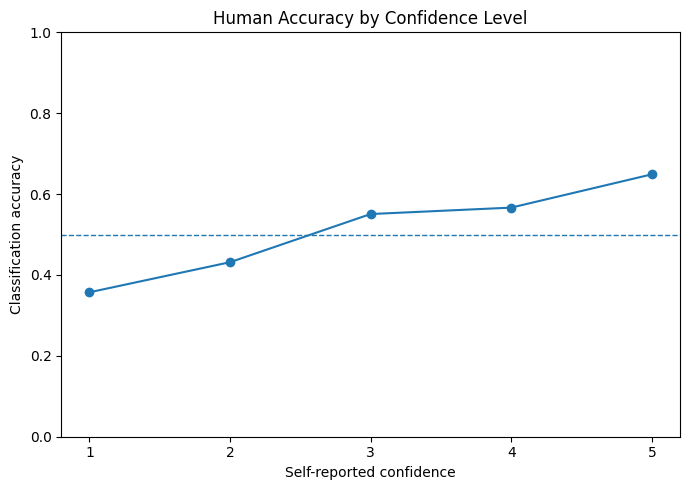

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(7, 5)
)


ax.plot(
    confidence_summary_df[
        "confidence"
    ],

    confidence_summary_df[
        "accuracy"
    ],

    marker="o"
)


ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)


ax.set_ylim(
    0,
    1
)


ax.set_xticks(
    [
        1,
        2,
        3,
        4,
        5
    ]
)


ax.set_xlabel(
    "Self-reported confidence"
)


ax.set_ylabel(
    "Classification accuracy"
)


ax.set_title(
    "Human Accuracy by Confidence Level"
)


fig.tight_layout()


fig.savefig(
    FIGURES_DIR /
    "human_accuracy_by_confidence.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## 38. Report Strict Class-Specific Majority Recall

Because the standard classification report excludes tied human majority judgments, strict class-specific recall is additionally calculated across the complete 120-review human evaluation set.

Tied reviews are treated as unresolved and therefore not correctly classified.

In [ ]:
strict_class_performance = (
    human_majority_df
    .groupby(
        "gold_label"
    )
    .agg(

        n_reviews=(
            "review_id",
            "count"
        ),

        n_correct=(
            "human_correct",
            "sum"
        )

    )
)


strict_class_performance[
    "strict_recall"
] = (
    strict_class_performance[
        "n_correct"
    ]
    /
    strict_class_performance[
        "n_reviews"
    ]
)


display(
    strict_class_performance
    .round(4)
)

,n_reviews,n_correct,strict_recall
gold_label,,,
deceptive,60,27,0.4500
truthful,60,47,0.7833


## 39. Explore Participant Background and Classification Performance

As a secondary exploratory analysis, participant-level classification accuracy is compared with two self-reported background variables collected in the questionnaire:

- English proficiency;
- familiarity with reading online reviews.

These analyses are conducted at the participant level, since each participant contributes multiple review judgments.

They are treated as exploratory rather than primary confirmatory analyses.

In [ ]:
participant_questionnaire_df = (
    load_all_participant_questionnaires()
)


print(
    "Questionnaire participants:",
    len(participant_questionnaire_df)
)


display(
    participant_questionnaire_df[
        [
            "participant_id",
            "english_proficiency",
            "review_familiarity"
        ]
    ].head()
)

Questionnaire participants: 38


,participant_id,english_proficiency,review_familiarity
0,B1_P001,4 — Advanced,Often
1,B1_P002,4 — Advanced,Never
2,B1_P003,3 — Intermediate,Sometimes
3,B1_P004,4 — Advanced,Very often
4,B1_P005,4 — Advanced,Often


In [ ]:
participant_questionnaire_df = (
    load_all_participant_questionnaires()
)


print(
    "Questionnaire participants:",
    len(participant_questionnaire_df)
)


display(
    participant_questionnaire_df[
        [
            "participant_id",
            "english_proficiency",
            "review_familiarity"
        ]
    ].head()
)

Questionnaire participants: 38


,participant_id,english_proficiency,review_familiarity
0,B1_P001,4 — Advanced,Often
1,B1_P002,4 — Advanced,Never
2,B1_P003,3 — Intermediate,Sometimes
3,B1_P004,4 — Advanced,Very often
4,B1_P005,4 — Advanced,Often


In [ ]:
participant_questionnaire_df = (
    load_all_participant_questionnaires()
)


participant_background_df = (
    participant_performance_df
    .merge(
        participant_questionnaire_df[
            [
                "participant_id",
                "english_proficiency",
                "review_familiarity"
            ]
        ],
        on="participant_id",
        how="left"
    )
)


print(
    "Participants:",
    len(participant_background_df)
)


print(
    "Missing English proficiency:",
    participant_background_df[
        "english_proficiency"
    ].isna().sum()
)


print(
    "Missing review familiarity:",
    participant_background_df[
        "review_familiarity"
    ].isna().sum()
)


display(
    participant_background_df.head()
)

Participants: 38
Missing English proficiency: 0
Missing review familiarity: 0


,participant_id,block,n_reviews,accuracy,mean_confidence,english_proficiency,review_familiarity
0,B1_P001,B1,20,0.55,3.65,4 — Advanced,Often
1,B1_P002,B1,20,0.60,3.25,4 — Advanced,Never
2,B1_P003,B1,20,0.50,3.80,3 — Intermediate,Sometimes
3,B1_P004,B1,20,0.50,3.50,4 — Advanced,Very often
4,B1_P005,B1,20,0.65,4.20,4 — Advanced,Often


In [ ]:
participant_background_df[
    "english_level"
] = (
    participant_background_df[
        "english_proficiency"
    ]
    .str.extract(
        r"^(\d)"
    )[0]
    .astype(int)
)

In [ ]:
FAMILIARITY_ORDER = {
    "Never": 1,
    "Rarely": 2,
    "Sometimes": 3,
    "Often": 4,
    "Very often": 5
}


participant_background_df[
    "review_familiarity_level"
] = (
    participant_background_df[
        "review_familiarity"
    ]
    .map(
        FAMILIARITY_ORDER
    )
)


display(
    participant_background_df[
        [
            "participant_id",
            "accuracy",
            "english_level",
            "review_familiarity_level"
        ]
    ].head()
)

,participant_id,accuracy,english_level,review_familiarity_level
0,B1_P001,0.55,4,4
1,B1_P002,0.60,4,1
2,B1_P003,0.50,3,3
3,B1_P004,0.50,4,5
4,B1_P005,0.65,4,4


## 40. Human Accuracy by English Proficiency

Participant-level accuracy is summarized across self-reported English proficiency levels.

Because the number of participants within each proficiency category may be small and unequal, both sample size and descriptive accuracy statistics are reported.

In [ ]:
english_accuracy_summary = (
    participant_background_df
    .groupby(
        "english_level"
    )
    .agg(

        n_participants=(
            "participant_id",
            "count"
        ),

        mean_accuracy=(
            "accuracy",
            "mean"
        ),

        median_accuracy=(
            "accuracy",
            "median"
        ),

        std_accuracy=(
            "accuracy",
            "std"
        )
    )
    .reset_index()
)


display(
    english_accuracy_summary.round(3)
)

,english_level,n_participants,mean_accuracy,median_accuracy,std_accuracy
0,2,1,0.600,0.60,NaN
1,3,13,0.527,0.50,0.078
2,4,22,0.561,0.60,0.117
3,5,2,0.650,0.65,0.000


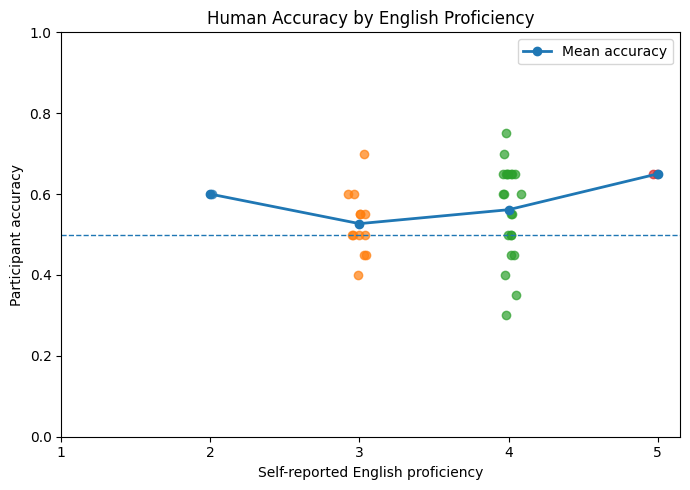

In [ ]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(
    figsize=(7, 5)
)


rng = np.random.default_rng(42)


for level in sorted(
    participant_background_df[
        "english_level"
    ].unique()
):

    subset = participant_background_df[
        participant_background_df[
            "english_level"
        ] == level
    ]


    jitter = rng.normal(
        0,
        0.04,
        size=len(subset)
    )


    ax.scatter(
        np.full(
            len(subset),
            level
        ) + jitter,

        subset[
            "accuracy"
        ],

        alpha=0.7
    )


mean_by_level = (
    participant_background_df
    .groupby(
        "english_level"
    )["accuracy"]
    .mean()
)


ax.plot(
    mean_by_level.index,
    mean_by_level.values,
    marker="o",
    linewidth=2,
    label="Mean accuracy"
)


ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)


ax.set_xticks(
    [1, 2, 3, 4, 5]
)


ax.set_ylim(
    0,
    1
)


ax.set_xlabel(
    "Self-reported English proficiency"
)


ax.set_ylabel(
    "Participant accuracy"
)


ax.set_title(
    "Human Accuracy by English Proficiency"
)


ax.legend()


fig.tight_layout()


fig.savefig(
    FIGURES_DIR /
    "human_accuracy_by_english_proficiency.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## 41. Human Accuracy by Online-Review Familiarity

Participant-level accuracy is summarized according to how frequently participants report reading online reviews when choosing hotels, products, restaurants or services.

In [ ]:
familiarity_accuracy_summary = (
    participant_background_df
    .groupby(
        [
            "review_familiarity_level",
            "review_familiarity"
        ],
        observed=True
    )
    .agg(

        n_participants=(
            "participant_id",
            "count"
        ),

        mean_accuracy=(
            "accuracy",
            "mean"
        ),

        median_accuracy=(
            "accuracy",
            "median"
        ),

        std_accuracy=(
            "accuracy",
            "std"
        )
    )
    .reset_index()
    .sort_values(
        "review_familiarity_level"
    )
)


display(
    familiarity_accuracy_summary.round(3)
)

,review_familiarity_level,review_familiarity,n_participants,mean_accuracy,median_accuracy,std_accuracy
0,1,Never,2,0.475,0.475,0.177
1,2,Rarely,7,0.543,0.500,0.137
2,3,Sometimes,8,0.506,0.525,0.068
3,4,Often,9,0.600,0.650,0.083
4,5,Very often,12,0.575,0.600,0.099


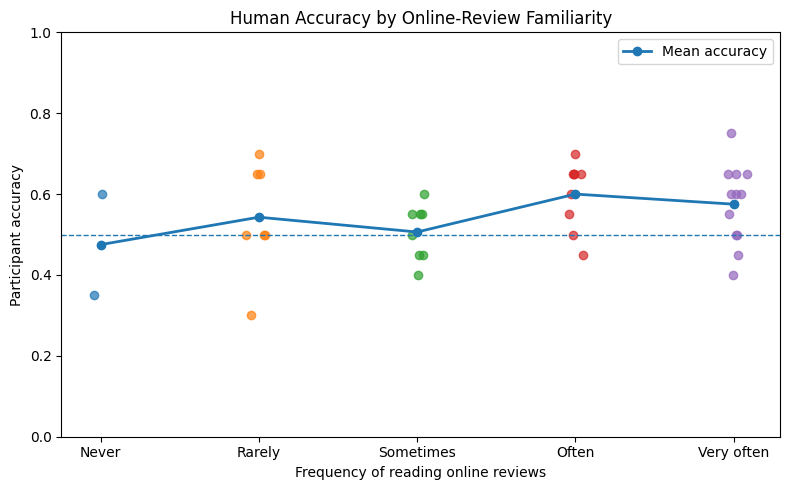

In [ ]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)


rng = np.random.default_rng(42)


for level in sorted(
    participant_background_df[
        "review_familiarity_level"
    ].dropna().unique()
):

    subset = participant_background_df[
        participant_background_df[
            "review_familiarity_level"
        ] == level
    ]


    jitter = rng.normal(
        0,
        0.04,
        size=len(subset)
    )


    ax.scatter(
        np.full(
            len(subset),
            level
        ) + jitter,

        subset[
            "accuracy"
        ],

        alpha=0.7
    )


mean_by_familiarity = (
    participant_background_df
    .groupby(
        "review_familiarity_level"
    )["accuracy"]
    .mean()
)


ax.plot(
    mean_by_familiarity.index,
    mean_by_familiarity.values,
    marker="o",
    linewidth=2,
    label="Mean accuracy"
)


ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)


ax.set_xticks(
    [1, 2, 3, 4, 5],

    labels=[
        "Never",
        "Rarely",
        "Sometimes",
        "Often",
        "Very often"
    ]
)


ax.set_ylim(
    0,
    1
)


ax.set_xlabel(
    "Frequency of reading online reviews"
)


ax.set_ylabel(
    "Participant accuracy"
)


ax.set_title(
    "Human Accuracy by Online-Review Familiarity"
)


ax.legend()


fig.tight_layout()


fig.savefig(
    FIGURES_DIR /
    "human_accuracy_by_review_familiarity.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## 42. Exploratory Associations with Participant Accuracy

Because English proficiency and online-review familiarity are ordinal self-reported variables, their associations with participant accuracy are summarized using Spearman rank correlations.

These analyses are exploratory and are not interpreted as evidence of causal effects.

In [ ]:
from scipy.stats import spearmanr


english_rho, english_p = spearmanr(
    participant_background_df[
        "english_level"
    ],

    participant_background_df[
        "accuracy"
    ]
)


familiarity_rho, familiarity_p = spearmanr(
    participant_background_df[
        "review_familiarity_level"
    ],

    participant_background_df[
        "accuracy"
    ]
)


print(
    "English proficiency vs accuracy"
)

print(
    "Spearman rho:",
    round(
        english_rho,
        4
    )
)

print(
    "p-value:",
    english_p
)


print(
    "\nReview familiarity vs accuracy"
)

print(
    "Spearman rho:",
    round(
        familiarity_rho,
        4
    )
)

print(
    "p-value:",
    familiarity_p
)

English proficiency vs accuracy
Spearman rho: 0.2735
p-value: 0.09664942872937164

Review familiarity vs accuracy
Spearman rho: 0.211
p-value: 0.20343597825904


### Block-Adjusted Sensitivity Analysis

In [ ]:
# Mean participant accuracy within each experimental block
block_accuracy_summary = (
    participant_background_df
    .groupby("block")
    .agg(
        n_participants=("participant_id", "count"),
        mean_accuracy=("accuracy", "mean"),
        median_accuracy=("accuracy", "median")
    )
    .reset_index()
)


display(
    block_accuracy_summary.round(3)
)


# Center each participant's accuracy around the mean
# accuracy of the block they evaluated.
participant_background_df[
    "block_mean_accuracy"
] = (
    participant_background_df
    .groupby("block")["accuracy"]
    .transform("mean")
)


participant_background_df[
    "block_centered_accuracy"
] = (
    participant_background_df["accuracy"]
    -
    participant_background_df["block_mean_accuracy"]
)


display(
    participant_background_df[
        [
            "participant_id",
            "block",
            "accuracy",
            "block_mean_accuracy",
            "block_centered_accuracy",
            "english_level",
            "review_familiarity_level"
        ]
    ].head()
)

,block,n_participants,mean_accuracy,median_accuracy
0,B1,5,0.560,0.550
1,B2,10,0.545,0.525
2,B3,5,0.550,0.600
3,B4,5,0.520,0.550
4,B5,7,0.550,0.550
5,B6,6,0.608,0.650


,participant_id,block,accuracy,block_mean_accuracy,block_centered_accuracy,english_level,review_familiarity_level
0,B1_P001,B1,0.55,0.56,-0.01,4,4
1,B1_P002,B1,0.60,0.56,0.04,4,1
2,B1_P003,B1,0.50,0.56,-0.06,3,3
3,B1_P004,B1,0.50,0.56,-0.06,4,5
4,B1_P005,B1,0.65,0.56,0.09,4,4


In [ ]:
from scipy.stats import spearmanr


english_adjusted_rho, english_adjusted_p = spearmanr(
    participant_background_df[
        "english_level"
    ],
    participant_background_df[
        "block_centered_accuracy"
    ]
)


familiarity_adjusted_rho, familiarity_adjusted_p = spearmanr(
    participant_background_df[
        "review_familiarity_level"
    ],
    participant_background_df[
        "block_centered_accuracy"
    ]
)


print(
    "BLOCK-ADJUSTED ASSOCIATIONS\n"
)


print(
    "English proficiency vs block-centered accuracy"
)

print(
    "Spearman rho:",
    round(
        english_adjusted_rho,
        4
    )
)

print(
    "p-value:",
    english_adjusted_p
)


print(
    "\nReview familiarity vs block-centered accuracy"
)

print(
    "Spearman rho:",
    round(
        familiarity_adjusted_rho,
        4
    )
)

print(
    "p-value:",
    familiarity_adjusted_p
)

BLOCK-ADJUSTED ASSOCIATIONS

English proficiency vs block-centered accuracy
Spearman rho: 0.1933
p-value: 0.24503376582267158

Review familiarity vs block-centered accuracy
Spearman rho: 0.19
p-value: 0.2533459182184225


In [ ]:
from scipy.stats import spearmanr


english_adjusted_rho, english_adjusted_p = spearmanr(
    participant_background_df[
        "english_level"
    ],
    participant_background_df[
        "block_centered_accuracy"
    ]
)


familiarity_adjusted_rho, familiarity_adjusted_p = spearmanr(
    participant_background_df[
        "review_familiarity_level"
    ],
    participant_background_df[
        "block_centered_accuracy"
    ]
)


print(
    "BLOCK-ADJUSTED ASSOCIATIONS\n"
)


print(
    "English proficiency vs block-centered accuracy"
)

print(
    "Spearman rho:",
    round(
        english_adjusted_rho,
        4
    )
)

print(
    "p-value:",
    english_adjusted_p
)


print(
    "\nReview familiarity vs block-centered accuracy"
)

print(
    "Spearman rho:",
    round(
        familiarity_adjusted_rho,
        4
    )
)

print(
    "p-value:",
    familiarity_adjusted_p
)

BLOCK-ADJUSTED ASSOCIATIONS

English proficiency vs block-centered accuracy
Spearman rho: 0.1933
p-value: 0.24503376582267158

Review familiarity vs block-centered accuracy
Spearman rho: 0.19
p-value: 0.2533459182184225


### Exploratory Background Associations

Self-reported English proficiency showed a small positive association with participant accuracy (Spearman's ρ = 0.27, p = .097).

Online-review familiarity showed a similarly small positive association with accuracy (ρ = 0.21, p = .203).

Neither association reached the conventional α = .05 significance threshold.

These results therefore provide no strong evidence that either English proficiency or familiarity with online reviews was systematically associated with deception-detection accuracy in this sample.

However, both associations were positive, so the results are compatible with the possibility of modest relationships that would require a larger sample to estimate more precisely.

Because these analyses were secondary and exploratory, they are interpreted descriptively rather than as confirmatory evidence.

## 43. Bootstrap Confidence Intervals for Exploratory Correlations

To quantify uncertainty around the exploratory Spearman correlations, participant-level bootstrap confidence intervals are estimated.

Participants, rather than individual judgments, are resampled because participant accuracy is the unit of analysis.

In [ ]:
from scipy.stats import spearmanr


def bootstrap_spearman_ci(
    dataframe,
    x_column,
    y_column,
    n_bootstrap=5000,
    random_seed=42
):

    rng = np.random.default_rng(
        random_seed
    )


    bootstrap_rhos = []


    for _ in range(
        n_bootstrap
    ):

        bootstrap_sample = (
            dataframe
            .sample(
                n=len(dataframe),
                replace=True,
                random_state=int(
                    rng.integers(
                        0,
                        1_000_000
                    )
                )
            )
        )


        rho, _ = spearmanr(
            bootstrap_sample[
                x_column
            ],

            bootstrap_sample[
                y_column
            ]
        )


        if not np.isnan(
            rho
        ):

            bootstrap_rhos.append(
                rho
            )


    lower = np.percentile(
        bootstrap_rhos,
        2.5
    )


    upper = np.percentile(
        bootstrap_rhos,
        97.5
    )


    return lower, upper

In [ ]:
english_ci = bootstrap_spearman_ci(
    participant_background_df,
    "english_level",
    "accuracy"
)


familiarity_ci = bootstrap_spearman_ci(
    participant_background_df,
    "review_familiarity_level",
    "accuracy"
)


print(
    "English proficiency:",
    f"rho = {english_rho:.3f}",
    f"95% bootstrap CI [{english_ci[0]:.3f}, {english_ci[1]:.3f}]"
)


print(
    "Review familiarity:",
    f"rho = {familiarity_rho:.3f}",
    f"95% bootstrap CI [{familiarity_ci[0]:.3f}, {familiarity_ci[1]:.3f}]"
)

English proficiency: rho = 0.273 95% bootstrap CI [-0.020, 0.542]
Review familiarity: rho = 0.211 95% bootstrap CI [-0.130, 0.522]


## 43. Sensitivity Analysis for Participant-Level Correlations

Because the participant-level exploratory analyses include only 38 participants, a sensitivity analysis is performed to quantify the magnitude of correlation that the study could reliably detect.

Rather than computing observed post-hoc power from the estimated correlations, which provides little information beyond the corresponding p-values, we estimate the minimum correlation detectable with 80% statistical power at a two-sided alpha level of .05.

The calculation uses the Fisher z approximation for correlation tests and should be interpreted as an approximate sensitivity analysis for the Spearman correlations.

In [ ]:
from scipy.stats import norm
import numpy as np


def correlation_power(
    rho,
    n,
    alpha=0.05
):

    fisher_z = np.arctanh(
        rho
    )

    effect = (
        fisher_z
        * np.sqrt(
            n - 3
        )
    )

    critical_z = norm.ppf(
        1 - alpha / 2
    )


    power = (
        1
        - norm.cdf(
            critical_z
            - effect
        )
        + norm.cdf(
            -critical_z
            - effect
        )
    )


    return power

In [ ]:
n_participants = (
    len(
        participant_background_df
    )
)


candidate_correlations = np.linspace(
    0.01,
    0.80,
    10000
)


candidate_powers = np.array([
    correlation_power(
        rho,
        n_participants
    )
    for rho
    in candidate_correlations
])


target_power = 0.80


closest_index = np.argmin(
    np.abs(
        candidate_powers
        - target_power
    )
)


minimum_detectable_rho = (
    candidate_correlations[
        closest_index
    ]
)


print(
    "Participants:",
    n_participants
)


print(
    "Alpha:",
    0.05
)


print(
    "Target power:",
    target_power
)


print(
    "Approximate minimum detectable correlation:",
    round(
        minimum_detectable_rho,
        3
    )
)

Participants: 38
Alpha: 0.05
Target power: 0.8
Approximate minimum detectable correlation: 0.441


### Sensitivity of the Exploratory Participant-Level Analyses

With 38 participants, the study had approximately 80% power to detect correlations of about |ρ| = .44 or larger at a two-sided α = .05 level.

The observed associations for English proficiency (ρ = .27) and online-review familiarity (ρ = .21) were smaller than this sensitivity threshold. Their bootstrap confidence intervals also included zero.

Therefore, the non-significant results should not be interpreted as evidence that these variables are unrelated to performance. Rather, the present sample provides insufficient precision to distinguish small-to-moderate associations from no association.

## 44. Match Human and Model Predictions

Qwen and RoBERTa predictions are restricted to the same 120 reviews used in the human experiment.

This ensures that human and model performance are compared on exactly the same set of items.

In [ ]:
model_human_subset_df = (
    load_model_predictions_for_human_set(
        human_design_df
    )
)


print(
    "Reviews:",
    len(model_human_subset_df)
)


print(
    "Unique review IDs:",
    model_human_subset_df[
        "review_id"
    ].nunique()
)


display(
    model_human_subset_df.head()
)

Reviews: 120
Unique review IDs: 120


,review_id,gold_label,block,qwen_prediction,roberta_prediction
0,R0446,deceptive,B1,deceptive,deceptive
1,R0483,deceptive,B1,deceptive,deceptive
2,R0699,deceptive,B1,deceptive,deceptive
3,R0771,deceptive,B1,deceptive,deceptive
4,R0296,truthful,B1,deceptive,deceptive


## 45. Build the Human–Model Comparison Dataset

Human majority judgments are merged with Qwen and RoBERTa predictions at the review level.

In [ ]:
human_model_comparison_df = (
    build_human_model_comparison(
        human_majority_df,
        model_human_subset_df
    )
)


print(
    "Reviews in comparison:",
    len(human_model_comparison_df)
)


print(
    "\nMissing values:"
)


display(
    human_model_comparison_df[
        [
            "human_prediction",
            "qwen_prediction",
            "roberta_prediction"
        ]
    ]
    .isna()
    .sum()
)


display(
    human_model_comparison_df.head()
)

Reviews in comparison: 120

Missing values:


,0
human_prediction,0
qwen_prediction,0
roberta_prediction,0


,review_id,block,gold_label,n_judgments,n_truthful,n_deceptive,human_prediction,human_correct,qwen_prediction,roberta_prediction,qwen_correct,roberta_correct
0,R0001,B1,truthful,5,3,2,truthful,True,deceptive,truthful,False,True
1,R0005,B6,truthful,6,5,1,truthful,True,deceptive,truthful,False,True
2,R0011,B2,truthful,10,9,1,truthful,True,deceptive,truthful,False,True
3,R0014,B4,truthful,5,5,0,truthful,True,deceptive,truthful,False,True
4,R0021,B6,truthful,6,6,0,truthful,True,truthful,truthful,True,True


## 46. Compare Performance on the Same 120 Reviews

Performance is first reported for all 120 reviews.

Human majority-vote ties are treated as unresolved and therefore as incorrect in the strict human accuracy measure.

Qwen and RoBERTa always provide a class prediction and are therefore evaluated on all 120 reviews.

In [ ]:
strict_human_accuracy = (
    human_model_comparison_df[
        "human_correct"
    ].mean()
)


qwen_120_accuracy = (
    human_model_comparison_df[
        "qwen_correct"
    ].mean()
)


roberta_120_accuracy = (
    human_model_comparison_df[
        "roberta_correct"
    ].mean()
)


print(
    "STRICT PERFORMANCE ON THE SAME 120 REVIEWS\n"
)


print(
    "Human majority:",
    round(
        strict_human_accuracy,
        4
    )
)


print(
    "Qwen:",
    round(
        qwen_120_accuracy,
        4
    )
)


print(
    "RoBERTa:",
    round(
        roberta_120_accuracy,
        4
    )
)

STRICT PERFORMANCE ON THE SAME 120 REVIEWS

Human majority: 0.6167
Qwen: 0.6
RoBERTa: 0.9167


## 47. Paired Comparison on Reviews with a Human Majority Decision

For paired human–model comparisons, reviews resulting in a tied human majority vote are excluded because no human class prediction is available.

Human majority, Qwen and RoBERTa are therefore compared on exactly the same decided reviews.

In [ ]:
human_model_results = (
    compare_humans_and_models(
        human_model_comparison_df
    )
)

Reviews with human majority decision: 117

Accuracy on identical decided reviews:
Humans: 0.6325
Qwen: 0.6068
RoBERTa: 0.9231


In [ ]:
decided_comparison_df = (
    human_model_comparison_df[
        human_model_comparison_df[
            "human_prediction"
        ] != "tie"
    ]
    .copy()
)


comparison_summary = pd.DataFrame({

    "system": [
        "Human majority",
        "Qwen",
        "RoBERTa"
    ],

    "n_reviews": [
        len(decided_comparison_df),
        len(decided_comparison_df),
        len(decided_comparison_df)
    ],

    "accuracy": [

        decided_comparison_df[
            "human_correct"
        ].mean(),

        decided_comparison_df[
            "qwen_correct"
        ].mean(),

        decided_comparison_df[
            "roberta_correct"
        ].mean()
    ]
})


display(
    comparison_summary.round(4)
)

,system,n_reviews,accuracy
0,Human majority,117,0.6325
1,Qwen,117,0.6068
2,RoBERTa,117,0.9231


## 48. Compare Class-Specific Recall

Class-specific recall is compared across humans, Qwen and RoBERTa on the same reviews receiving a human majority decision.

This allows differences in overall accuracy to be distinguished from systematic differences in class bias.

In [ ]:
from sklearn.metrics import recall_score


systems = {
    "Human majority":
        "human_prediction",

    "Qwen":
        "qwen_prediction",

    "RoBERTa":
        "roberta_prediction"
}


class_recall_rows = []


for system_name, prediction_column in (
    systems.items()
):

    truthful_recall = recall_score(
        decided_comparison_df[
            "gold_label"
        ],
        decided_comparison_df[
            prediction_column
        ],
        pos_label="truthful"
    )


    deceptive_recall = recall_score(
        decided_comparison_df[
            "gold_label"
        ],
        decided_comparison_df[
            prediction_column
        ],
        pos_label="deceptive"
    )


    class_recall_rows.append({

        "system":
            system_name,

        "truthful_recall":
            truthful_recall,

        "deceptive_recall":
            deceptive_recall
    })


class_recall_df = pd.DataFrame(
    class_recall_rows
)


display(
    class_recall_df.round(4)
)

,system,truthful_recall,deceptive_recall
0,Human majority,0.8246,0.4500
1,Qwen,0.4386,0.7667
2,RoBERTa,0.9123,0.9333


In [ ]:
HUMAN_MODEL_COMPARISON_PATH = (
    PROCESSED_HUMAN_DIR /
    "human_model_comparison_120.csv"
)


human_model_comparison_df.to_csv(
    HUMAN_MODEL_COMPARISON_PATH,
    index=False
)


print(
    "Saved:",
    HUMAN_MODEL_COMPARISON_PATH
)

Saved: /content/drive/MyDrive/HLT_project/human_experiment/processed/human_model_comparison_120.csv


## 47. Exact Paired Human–Model Comparisons

Because the systems classify the same reviews, differences in accuracy are evaluated using exact McNemar tests based only on discordant item-level outcomes.

The analysis is restricted to the 117 reviews for which a human majority decision was available.

In [ ]:
from scipy.stats import binomtest


def exact_mcnemar(
    dataframe,
    system_a_correct,
    system_b_correct
):

    a_only = (
        dataframe[
            system_a_correct
        ]
        &
        ~dataframe[
            system_b_correct
        ]
    ).sum()


    b_only = (
        ~dataframe[
            system_a_correct
        ]
        &
        dataframe[
            system_b_correct
        ]
    ).sum()


    n_discordant = (
        a_only
        +
        b_only
    )


    if n_discordant == 0:

        p_value = 1.0

    else:

        p_value = binomtest(
            min(
                a_only,
                b_only
            ),
            n=n_discordant,
            p=0.5,
            alternative="two-sided"
        ).pvalue


    return {
        "a_only_correct": int(
            a_only
        ),
        "b_only_correct": int(
            b_only
        ),
        "discordant_reviews": int(
            n_discordant
        ),
        "p_value": p_value
    }

In [ ]:
human_vs_qwen = exact_mcnemar(
    decided_comparison_df,
    "human_correct",
    "qwen_correct"
)


human_vs_roberta = exact_mcnemar(
    decided_comparison_df,
    "human_correct",
    "roberta_correct"
)


qwen_vs_roberta = exact_mcnemar(
    decided_comparison_df,
    "qwen_correct",
    "roberta_correct"
)


print(
    "HUMANS vs QWEN"
)

print(
    human_vs_qwen
)


print(
    "\nHUMANS vs RoBERTa"
)

print(
    human_vs_roberta
)


print(
    "\nQWEN vs RoBERTa"
)

print(
    qwen_vs_roberta
)

HUMANS vs QWEN
{'a_only_correct': 29, 'b_only_correct': 26, 'discordant_reviews': 55, 'p_value': np.float64(0.7877061896700431)}

HUMANS vs RoBERTa
{'a_only_correct': 2, 'b_only_correct': 36, 'discordant_reviews': 38, 'p_value': np.float64(5.398760549724102e-09)}

QWEN vs RoBERTa
{'a_only_correct': 3, 'b_only_correct': 40, 'discordant_reviews': 43, 'p_value': np.float64(3.0213413992896676e-09)}


## 48. Inspect Paired Correctness Patterns

Paired correctness tables are used to determine whether systems tend to succeed and fail on the same reviews.

In [ ]:
print(
    "HUMANS × QWEN\n"
)


display(
    pd.crosstab(
        decided_comparison_df[
            "human_correct"
        ],
        decided_comparison_df[
            "qwen_correct"
        ],
        rownames=[
            "Human correct"
        ],
        colnames=[
            "Qwen correct"
        ]
    )
)


print(
    "\nHUMANS × RoBERTa\n"
)


display(
    pd.crosstab(
        decided_comparison_df[
            "human_correct"
        ],
        decided_comparison_df[
            "roberta_correct"
        ],
        rownames=[
            "Human correct"
        ],
        colnames=[
            "RoBERTa correct"
        ]
    )
)

HUMANS × QWEN



Qwen correct,False,True
Human correct,,
False,17,26
True,29,45



HUMANS × RoBERTa



RoBERTa correct,False,True
Human correct,,
False,7,36
True,2,72


## 49. Compare Three-Way Error Patterns

Review-level correctness patterns are examined jointly across humans, Qwen and RoBERTa to identify shared and system-specific successes and failures.

In [ ]:
three_way_patterns = (
    decided_comparison_df
    .groupby(
        [
            "human_correct",
            "qwen_correct",
            "roberta_correct"
        ]
    )
    .size()
    .reset_index(
        name="n_reviews"
    )
    .sort_values(
        "n_reviews",
        ascending=False
    )
)


display(
    three_way_patterns
)


print(
    "\nTotal:",
    three_way_patterns[
        "n_reviews"
    ].sum()
)

,human_correct,qwen_correct,roberta_correct,n_reviews
6,True,True,True,45
5,True,False,True,27
3,False,True,True,23
1,False,False,True,13
0,False,False,False,4
2,False,True,False,3
4,True,False,False,2



Total: 117


### Paired Human–Model Comparisons

On the 117 reviews for which a human majority decision was available, human majority accuracy was 63.25%, compared with 60.68% for Qwen and 92.31% for RoBERTa.

An exact McNemar test found no evidence of a difference in accuracy between human majority judgments and Qwen (29 human-only correct reviews versus 26 Qwen-only correct reviews; p = .788).

However, the similar aggregate accuracy concealed substantial item-level disagreement: humans and Qwen differed in correctness on 55 of the 117 reviews (47.0%). Thus, similar overall accuracy did not imply that the two systems succeeded and failed on the same items.

RoBERTa substantially outperformed both comparison systems. Relative to humans, RoBERTa was uniquely correct on 36 reviews while humans were uniquely correct on only 2 (exact McNemar p < .001). Relative to Qwen, RoBERTa was uniquely correct on 40 reviews while Qwen was uniquely correct on only 3 (p < .001).

These results should be interpreted in light of the different learning conditions: RoBERTa was trained specifically on this corpus, whereas the human participants and Qwen received no task-specific training.

## Human Behavior on Reviews Misclassified by RoBERTa

As an exploratory error analysis, human judgments are examined specifically for reviews that RoBERTa misclassified within the 120-review human evaluation subset.

Because the human evaluation sample was selected independently of model predictions, these items were not deliberately chosen based on RoBERTa performance.

The analysis is descriptive and investigates whether RoBERTa errors also tend to be difficult for human judges and for Qwen.

In [ ]:
roberta_error_ids = (
    human_model_comparison_df.loc[
        ~human_model_comparison_df[
            "roberta_correct"
        ],
        "review_id"
    ]
    .tolist()
)


print(
    "RoBERTa errors in human subset:",
    len(roberta_error_ids)
)

RoBERTa errors in human subset: 10


In [ ]:
human_on_roberta_errors = (
    human_long_df[
        human_long_df[
            "review_id"
        ].isin(
            roberta_error_ids
        )
    ]
    .groupby(
        "review_id"
    )
    .agg(

        n_human_judgments=(
            "prediction",
            "count"
        ),

        human_accuracy=(
            "correct",
            "mean"
        ),

        mean_confidence=(
            "confidence",
            "mean"
        ),

        truthful_votes=(
            "prediction",
            lambda x: (
                x == "truthful"
            ).sum()
        ),

        deceptive_votes=(
            "prediction",
            lambda x: (
                x == "deceptive"
            ).sum()
        )

    )
    .reset_index()
)

In [ ]:
roberta_error_analysis_df = (
    human_model_comparison_df[
        human_model_comparison_df[
            "review_id"
        ].isin(
            roberta_error_ids
        )
    ]
    .merge(
        human_on_roberta_errors,
        on="review_id",
        how="left"
    )
)


display(
    roberta_error_analysis_df[
        [
            "review_id",
            "gold_label",
            "human_prediction",
            "qwen_prediction",
            "roberta_prediction",
            "n_human_judgments",
            "truthful_votes",
            "deceptive_votes",
            "human_accuracy",
            "mean_confidence"
        ]
    ]
    .sort_values(
        "human_accuracy"
    )
    .round(3)
)

,review_id,gold_label,human_prediction,qwen_prediction,roberta_prediction,n_human_judgments,truthful_votes,deceptive_votes,human_accuracy,mean_confidence
6,R0524,deceptive,truthful,truthful,truthful,5,5,0,0.000,3.600
8,R0598,deceptive,truthful,deceptive,truthful,5,4,1,0.200,3.400
9,R0671,deceptive,truthful,deceptive,truthful,7,5,2,0.286,3.286
4,R0304,truthful,deceptive,deceptive,deceptive,6,2,4,0.333,3.333
7,R0582,deceptive,truthful,truthful,truthful,10,6,4,0.400,3.800
5,R0381,truthful,deceptive,truthful,deceptive,5,2,3,0.400,3.200
1,R0111,truthful,deceptive,deceptive,deceptive,10,4,6,0.400,3.300
2,R0242,truthful,tie,deceptive,deceptive,10,5,5,0.500,3.700
0,R0074,truthful,truthful,deceptive,deceptive,5,3,2,0.600,3.400
3,R0296,truthful,truthful,deceptive,deceptive,5,4,1,0.800,4.600


In [ ]:
print(
    "ROBERta ERROR SUBSET\n"
)


print(
    "Number of reviews:",
    len(
        roberta_error_analysis_df
    )
)


print(
    "Mean proportion of correct human judgments:",
    round(
        roberta_error_analysis_df[
            "human_accuracy"
        ].mean(),
        4
    )
)


print(
    "Human majority correct:",
    roberta_error_analysis_df[
        "human_correct"
    ].sum()
)


print(
    "Human majority ties:",
    (
        roberta_error_analysis_df[
            "human_prediction"
        ] == "tie"
    ).sum()
)


print(
    "Qwen correct:",
    roberta_error_analysis_df[
        "qwen_correct"
    ].sum()
)

ROBERta ERROR SUBSET

Number of reviews: 10
Mean proportion of correct human judgments: 0.3919
Human majority correct: 2
Human majority ties: 1
Qwen correct: 3


### Human and Qwen Performance on RoBERTa Errors

Ten of the 120 reviews included in the human experiment were misclassified by RoBERTa.

These reviews also appeared challenging for the other decision makers. Across individual human judgments, mean review-level proportion of correct human judgments on the RoBERTa-error subset was only **39.19%**, compared with **55.53%** across the complete human experiment.

At the aggregate level, the human majority correctly classified only **2 of the 10** RoBERTa errors, with one additional review resulting in a tie. Qwen correctly classified **3 of the 10** reviews.

Thus, many RoBERTa errors were not cases that humans could easily resolve. Instead, the overlap in difficulty across systems suggests that at least some of these reviews may represent particularly ambiguous, atypical, or corpus-inconsistent cases.

This analysis is exploratory because the subset is defined conditionally on RoBERTa errors and should not be interpreted as an independent estimate of item difficulty.

In [ ]:
print(
    "Gold-label distribution among RoBERTa errors:"
)


print(
    roberta_error_analysis_df[
        "gold_label"
    ].value_counts()
)

Gold-label distribution among RoBERTa errors:
gold_label
truthful     6
deceptive    4
Name: count, dtype: int64


In [ ]:
overall_mean_confidence = (
    human_long_df[
        "confidence"
    ].mean()
)


roberta_error_mean_confidence = (
    human_long_df[
        human_long_df[
            "review_id"
        ].isin(
            roberta_error_ids
        )
    ][
        "confidence"
    ]
    .mean()
)


print(
    "Mean confidence - all human judgments:",
    round(
        overall_mean_confidence,
        3
    )
)


print(
    "Mean confidence - RoBERTa error reviews:",
    round(
        roberta_error_mean_confidence,
        3
    )
)

Mean confidence - all human judgments: 3.568
Mean confidence - RoBERTa error reviews: 3.559


## 50. Direction of RoBERTa Error Recovery

To determine whether the apparent complementarity between humans and Qwen may reflect their different class biases, the gold labels of RoBERTa errors recovered by each system are examined.

If human-only recoveries are predominantly truthful while Qwen-only recoveries are predominantly deceptive, the pattern would be consistent with the previously observed human truth bias and Qwen deception bias.

In [ ]:
human_recovered = (
    roberta_error_analysis_df[
        roberta_error_analysis_df[
            "human_correct"
        ]
    ]
    .copy()
)


qwen_recovered = (
    roberta_error_analysis_df[
        roberta_error_analysis_df[
            "qwen_correct"
        ]
    ]
    .copy()
)


print(
    "ROBERta ERRORS RECOVERED BY HUMANS\n"
)


print(
    human_recovered[
        [
            "review_id",
            "gold_label",
            "human_prediction",
            "qwen_prediction",
            "roberta_prediction"
        ]
    ].to_string(
        index=False
    )
)


print(
    "\nGold labels:"
)


print(
    human_recovered[
        "gold_label"
    ].value_counts()
)


print(
    "\n\nROBERta ERRORS RECOVERED BY QWEN\n"
)


print(
    qwen_recovered[
        [
            "review_id",
            "gold_label",
            "human_prediction",
            "qwen_prediction",
            "roberta_prediction"
        ]
    ].to_string(
        index=False
    )
)


print(
    "\nGold labels:"
)


print(
    qwen_recovered[
        "gold_label"
    ].value_counts()
)

ROBERta ERRORS RECOVERED BY HUMANS

review_id gold_label human_prediction qwen_prediction roberta_prediction
    R0074   truthful         truthful       deceptive          deceptive
    R0296   truthful         truthful       deceptive          deceptive

Gold labels:
gold_label
truthful    2
Name: count, dtype: int64


ROBERta ERRORS RECOVERED BY QWEN

review_id gold_label human_prediction qwen_prediction roberta_prediction
    R0381   truthful        deceptive        truthful          deceptive
    R0598  deceptive         truthful       deceptive           truthful
    R0671  deceptive         truthful       deceptive           truthful

Gold labels:
gold_label
deceptive    2
truthful     1
Name: count, dtype: int64


In [ ]:
print(
    "GOLD LABELS OF ALL 10 ROBERTA ERRORS\n"
)


print(
    roberta_error_analysis_df[
        "gold_label"
    ].value_counts()
)


print(
    "\nHuman predictions on RoBERTa errors:"
)


print(
    roberta_error_analysis_df[
        "human_prediction"
    ].value_counts()
)


print(
    "\nQwen predictions on RoBERTa errors:"
)


print(
    roberta_error_analysis_df[
        "qwen_prediction"
    ].value_counts()
)

GOLD LABELS OF ALL 10 ROBERTA ERRORS

gold_label
truthful     6
deceptive    4
Name: count, dtype: int64

Human predictions on RoBERTa errors:
human_prediction
truthful     6
deceptive    3
tie          1
Name: count, dtype: int64

Qwen predictions on RoBERTa errors:
qwen_prediction
deceptive    7
truthful     3
Name: count, dtype: int64


In [ ]:
print(
    "HUMAN MAJORITY PREDICTIONS — ALL 120\n"
)


print(
    human_model_comparison_df[
        "human_prediction"
    ].value_counts()
)


print(
    "\nQWEN PREDICTIONS — ALL 120\n"
)


print(
    human_model_comparison_df[
        "qwen_prediction"
    ].value_counts()
)

HUMAN MAJORITY PREDICTIONS — ALL 120

human_prediction
truthful     80
deceptive    37
tie           3
Name: count, dtype: int64

QWEN PREDICTIONS — ALL 120

qwen_prediction
deceptive    80
truthful     40
Name: count, dtype: int64


### Direction of Error Recovery

The apparently complementary recovery of RoBERTa errors was strongly aligned with the class biases observed for humans and Qwen.

Among the ten RoBERTa errors, six reviews were truthful and four were deceptive. Human majority judgments recovered only two reviews, both of which were truthful. Consequently, human majority recall within this subset was 33.3% for truthful reviews and 0% for deceptive reviews.

Qwen recovered three RoBERTa errors: two deceptive reviews and one truthful review, corresponding to recall rates of 50.0% and 16.7%, respectively.

Importantly, prediction tendencies on the RoBERTa-error subset closely resembled the systems' global biases. Humans predicted truthful on 66.7% of decided RoBERTa-error cases, compared with 68.4% across all of their decided reviews. Qwen predicted deceptive on 70.0% of RoBERTa errors, compared with 66.7% across the complete 120-review subset.

Thus, the system-specific recovery patterns may be explained at least partly by their opposing class preferences rather than by uniquely complementary abilities to identify difficult reviews.

In [ ]:
roberta_error_bias_summary = pd.DataFrame({

    "system": [
        "Human majority",
        "Qwen"
    ],

    "truthful_recall_on_roberta_errors": [
        2 / 6,
        1 / 6
    ],

    "deceptive_recall_on_roberta_errors": [
        0 / 4,
        2 / 4
    ],

    "dominant_prediction_on_errors": [
        "truthful",
        "deceptive"
    ],

    "dominant_prediction_rate_on_errors": [
        6 / 9,
        7 / 10
    ],

    "dominant_prediction_rate_overall": [
        80 / 117,
        80 / 120
    ]
})


display(
    roberta_error_bias_summary.round(3)
)

,system,truthful_recall_on_roberta_errors,deceptive_recall_on_roberta_errors,dominant_prediction_on_errors,dominant_prediction_rate_on_errors,dominant_prediction_rate_overall
0,Human majority,0.333,0.0,truthful,0.667,0.684
1,Qwen,0.167,0.5,deceptive,0.700,0.667


## 51.Read the 10 Reviews




In [ ]:
CLEAN_DATA_PATH = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "positive_deceptive_reviews_clean.csv"
)


df_clean = pd.read_csv(
    CLEAN_DATA_PATH
)


print(
    "Reviews loaded:",
    len(df_clean)
)


print(
    "Unique review IDs:",
    df_clean[
        "review_id"
    ].nunique()
)


display(
    df_clean[
        [
            "review_id",
            "text",
            "label"
        ]
    ].head()
)

Reviews loaded: 800
Unique review IDs: 800


,review_id,text,label
0,R0000,We stayed for a one night getaway with family ...,truthful
1,R0001,Triple A rate with upgrade to view room was le...,truthful
2,R0002,This comes a little late as I'm finally catchi...,truthful
3,R0003,The Omni Chicago really delivers on all fronts...,truthful
4,R0004,I asked for a high floor away from the elevato...,truthful


In [ ]:
roberta_error_text_df = (
    roberta_error_analysis_df
    .merge(
        df_clean[
            [
                "review_id",
                "text"
            ]
        ],
        on="review_id",
        how="left"
    )
)


for _, row in (
    roberta_error_text_df
    .sort_values(
        "human_accuracy"
    )
    .iterrows()
):

    print(
        "=" * 80
    )

    print(
        "Review:",
        row["review_id"]
    )

    print(
        "Gold:",
        row["gold_label"]
    )

    print(
        "RoBERTa:",
        row["roberta_prediction"]
    )

    print(
        "Qwen:",
        row["qwen_prediction"]
    )

    print(
        "Human majority:",
        row["human_prediction"]
    )

    print(
        "Human accuracy:",
        round(
            row["human_accuracy"],
            3
        )
    )

    print(
        "Mean confidence:",
        round(
            row["mean_confidence"],
            2
        )
    )

    print(
        "\nTEXT:\n"
    )

    print(
        row["text"]
    )

    print()

Review: R0524
Gold: deceptive
RoBERTa: truthful
Qwen: truthful
Human majority: truthful
Human accuracy: 0.0
Mean confidence: 3.6

TEXT:

Very nice hotel, better than expected. The hot breakfast is great in the morning, but the Dinner at night goes above and beyond (even free wine!) The rooms are pretty good size, well furnished, and clean. I liked the view from my room. I used the fitness center and although did not have everything I would have liked, was adequate. I will say the pool is really nice and offers a pretty sweet view. The staff was friendly and helpful; being my first time in Chicago they were able to point me in the right direction and saved me some frustration. I would definitely recommend this hotel. 


Review: R0598
Gold: deceptive
RoBERTa: truthful
Qwen: deceptive
Human majority: truthful
Human accuracy: 0.2
Mean confidence: 3.4

TEXT:

Although much too overpriced in my opinion, the hotel is spotless. The staff was very courteous. And the spa service ? Was a God send

### Qualitative Inspection of Shared and System-Specific Errors

Qualitative inspection of the ten RoBERTa errors revealed that several difficult reviews contained linguistic characteristics that could plausibly support the opposite label.

Some deceptive reviews contained concrete episodic details, first-person experiences, balanced evaluations, and specific situational information. For example, R0524 included references to hotel facilities, a room view, receiving directions from staff, and even a minor negative evaluation. Nevertheless, the review was deceptive and was classified as truthful by all three decision makers.

Conversely, several truthful reviews exhibited strongly promotional, persuasive, or exaggerated language. R0304, for example, described the stay as one of the best hotel experiences of the reviewer's professional life and used multiple superlative evaluations. It was classified as deceptive by humans, Qwen, and RoBERTa despite being truthful.

These cases illustrate that intuitive linguistic cues are not deterministic indicators of deception. Reviews may display characteristics stereotypically associated with authenticity while being deceptive, or characteristics associated with fabricated promotional writing while being truthful.

The system-specific recoveries also suggest that global class biases explain only part of the disagreement. Human-only recoveries were both truthful, consistent with the human truth bias. Qwen recovered two deceptive reviews, consistent with its deception bias, but also correctly recovered one truthful review that humans and RoBERTa misclassified.

These observations are treated as exploratory qualitative evidence rather than as direct evidence of the internal features used by either model.